# Обзор бизнес-показателей маркетплейса

## Цель проекта:
Провести комплексный анализ бизнес-показателей маркетплейса, выявить точки роста и сформулировать рекомендации для развития продукта.

## План проекта: 
- Первичный анализ и сбор данных.
- Обзор ключевых метрик.
- Оценка метрик монетизации и юнит-экономики.
- Поиск инсайтов и точек роста. Сегментация и формулирование гипотез.
- Подготовка эксперимента и подведение его итогов.

# Импорт библиотек, загрузка и предобработка данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu
import numpy as np


In [ ]:
pa_marketplace_orders = pd.read_csv('',parse_dates=['order_date','order_week','order_month'])


In [ ]:
pa_marketplace_campaign_costs = pd.read_csv('', parse_dates=['spend_month'])


In [ ]:
pa_marketplace_users = pd.read_csv('',parse_dates=['registration_date','cohort_week','cohort_month'])


In [ ]:
pa_marketplace_events = pd.read_csv('',parse_dates=['event_date','event_week','event_month'])

### Предобработка данных
#### Датасет `pa_marketplace_orders`

In [6]:
pa_marketplace_orders.sort_values(by='order_date').head()

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
116,117,100,2024-01-01 08:03:45,Стеллаж для книг,2,15689.87,31379.74,Мебель для дома,2024-01-01,2024-01-01
76,77,45,2024-01-02 01:32:02,Помада матовая,2,7632.66,15265.32,Косметика и парфюмерия,2024-01-01,2024-01-01
77,78,48,2024-01-02 09:28:48,Утюг с паром,1,17791.27,17791.27,Бытовая техника,2024-01-01,2024-01-01
185,186,159,2024-01-03 01:27:35,Baseus зарядка,3,11751.87,35255.61,Аксессуары для гаджетов,2024-01-01,2024-01-01
147,148,101,2024-01-03 04:35:08,Толстовка с капюшоном,3,5150.47,15451.41,Одежда для спорта,2024-01-01,2024-01-01


In [7]:
pa_marketplace_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31357 entries, 0 to 31356
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       31357 non-null  int64         
 1   user_id        31357 non-null  int64         
 2   order_date     31357 non-null  datetime64[ns]
 3   product_name   31357 non-null  object        
 4   quantity       31357 non-null  int64         
 5   unit_price     31357 non-null  float64       
 6   total_price    31357 non-null  float64       
 7   category_name  31357 non-null  object        
 8   order_week     31357 non-null  datetime64[ns]
 9   order_month    31357 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(3), object(2)
memory usage: 2.4+ MB


Пропуски в датасете `pa_marketplace_orders` отсутствуют. Данные соответствуют описанию, типы данных корректны.

In [8]:
pa_marketplace_orders['order_date'].describe()

count                            31357
mean     2024-07-05 07:41:06.424753664
min                2024-01-01 08:03:45
25%                2024-04-21 20:29:34
50%                2024-07-03 16:44:57
75%                2024-09-14 17:05:31
max                2024-12-31 23:00:53
Name: order_date, dtype: object

Датасет содержит записи о заказах, совершенных с 1 января по 31 декабря 2024 года.

In [9]:
pa_marketplace_orders.duplicated().sum()

0

Явные дубликаты также отсутствуют.

In [10]:
sorted(pa_marketplace_orders['category_name'].unique())

['Автотовары',
 'Аксессуары для гаджетов',
 'Бытовая техника',
 'Декор и освещение',
 'Детская одежда',
 'Детские игрушки',
 'Женская одежда',
 'Зоотовары',
 'Инструменты и садовый инвентарь',
 'Книги и канцтовары',
 'Косметика и парфюмерия',
 'Мебель для дома',
 'Медицинские товары',
 'Мужская одежда',
 'Обувь женская',
 'Обувь мужская',
 'Одежда для спорта',
 'Продукты питания',
 'Спортивный инвентарь',
 'Средства для ухода',
 'Сумки и аксессуары',
 'Товары для кухни',
 'Товары для новорожденных',
 'Товары для туризма',
 'Украшения и часы']

Неявные дубликаты в категориальном столбце `category_name` отсутствуют.

In [11]:
pa_marketplace_orders[pa_marketplace_orders.duplicated(subset=['user_id','order_date','total_price'],keep=False)]

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
232,233,203,2024-02-07 22:19:44,Тетрадь общая,1,2829.81,2829.81,Книги и канцтовары,2024-02-05,2024-02-01
233,234,203,2024-02-07 22:19:44,Тетрадь общая,1,2829.81,2829.81,Книги и канцтовары,2024-02-05,2024-02-01
459,460,362,2024-01-26 02:59:13,Свечи зажигания,3,7696.64,23089.92,Автотовары,2024-01-22,2024-01-01
460,461,362,2024-01-26 02:59:13,Свечи зажигания,3,7696.64,23089.92,Автотовары,2024-01-22,2024-01-01
562,563,420,2024-01-13 19:39:50,Чайник электрический,3,6254.47,18763.41,Товары для кухни,2024-01-08,2024-01-01
...,...,...,...,...,...,...,...,...,...,...
30863,31095,41025,2024-12-07 21:50:56,Бинт эластичный,1,1152.21,1152.21,Медицинские товары,2024-12-02,2024-12-01
31092,31368,42209,2024-12-12 08:18:11,Подушки декоративные,1,6717.61,6717.61,Декор и освещение,2024-12-09,2024-12-01
31093,31369,42209,2024-12-12 08:18:11,Подушки декоративные,1,6717.61,6717.61,Декор и освещение,2024-12-09,2024-12-01
31253,31572,43300,2024-12-31 07:53:21,Рубашка классическая,3,2356.25,7068.75,Мужская одежда,2024-12-30,2024-12-01


In [12]:
#Удалим дубликаты и переименуем датафрейм для более удобной работы в дальнейшем
orders=pa_marketplace_orders.drop_duplicates(subset=['user_id','order_date','total_price'], keep='first', inplace=False).reset_index(drop=True)


In [13]:
#Проверим корректность в столбцах unit_price и total_price
orders['delta']=orders['quantity']*orders['unit_price']-orders['total_price']
orders[orders['delta']>=0.01]['delta'].unique()

array([0.01])

В 74 строках имeется ошибка округления в цене товара в 0.01 у.е.. В рамках настоящей задачи будем придерживаться предположения, что корректной является сумма заказа.

In [14]:
print(f'Датасет очищен от {len(pa_marketplace_orders)-len(orders)} дубликатов по ID пользователя, дате и времени заказа и сумме заказа')

Датасет очищен от 270 дубликатов по ID пользователя, дате и времени заказа и сумме заказа


#### Датасет `pa_marketplace_campaign_costs`

In [15]:
pa_marketplace_campaign_costs.head()

,Unnamed: 0,acq_channel,spend_month,budget
0,0,Affiliate,2024-01-01,179343.3875
1,1,Affiliate,2024-02-01,175488.4875
2,2,Affiliate,2024-03-01,164543.4750
3,3,Affiliate,2024-04-01,186869.9750
4,4,Affiliate,2024-05-01,166443.7750


In [16]:
pa_marketplace_campaign_costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Unnamed: 0   88 non-null     int64         
 1   acq_channel  88 non-null     object        
 2   spend_month  88 non-null     datetime64[ns]
 3   budget       88 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 2.9+ KB


Пропуски в датасете `pa_marketplace_campaign_costs` отсутствуют. Данные соответствуют описанию, типы данных корректны. Присутствует лишний столбец, дублирующий индекс - `Unnamed: 0`, его следует удалить.

In [17]:
pa_marketplace_campaign_costs['spend_month'].describe()

count                               88
mean     2024-06-26 09:49:05.454545408
min                2024-01-01 00:00:00
25%                2024-04-01 00:00:00
50%                2024-07-01 00:00:00
75%                2024-10-01 00:00:00
max                2025-01-01 00:00:00
Name: spend_month, dtype: object

Датасет содержит записи о маркетинговых тратах, совершенных с 1 января 2024 года по 1 января 2025 года. Отфильтруем данные за январь 2025 года, поскольку исследовать планируется только данные за 2024 год.

In [18]:
campaign_costs=pa_marketplace_campaign_costs[pa_marketplace_campaign_costs['spend_month']<='2024-12-31']

In [19]:
len(pa_marketplace_campaign_costs)-len(campaign_costs)

6

Отфильтровано 6 строк с данными о маркетинговых тратах в январе 2025 года.

In [20]:
#Удалим лишний столбец и переименуем датафрейм для более удобной работы в дальнейшем
campaign_costs=campaign_costs.iloc[:,1:]

In [21]:
campaign_costs.duplicated().sum()

0


Явные дубликаты отсутствуют.

In [22]:
campaign_costs.duplicated(subset=['acq_channel','spend_month'],keep=False).sum()

0

Отсутствуют неявные дубликаты по каналу привлечения и месяцу.

#### Датасет `pa_marketplace_users`

In [23]:
pa_marketplace_users.head()

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,1,2024-01-01 00:47:00,35,M,Москва,Google Ads,regular,2024-01-01,2024-01-01
1,2,2024-01-01 19:01:00,53,M,Москва,Email Marketing,rare,2024-01-01,2024-01-01
2,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01
3,4,2024-01-01 17:18:00,58,M,Краснодар,Affiliate,one_time,2024-01-01,2024-01-01
4,5,2024-01-01 08:29:00,58,F,Другие регионы,Google Ads,regular,2024-01-01,2024-01-01


In [24]:
pa_marketplace_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44151 entries, 0 to 44150
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            44151 non-null  int64         
 1   registration_date  44151 non-null  datetime64[ns]
 2   age                44151 non-null  int64         
 3   gender             44151 non-null  object        
 4   region             44151 non-null  object        
 5   acq_channel        44151 non-null  object        
 6   buyer_segment      44151 non-null  object        
 7   cohort_week        44151 non-null  datetime64[ns]
 8   cohort_month       44151 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 3.0+ MB


Данные соответствуют описанию, типы данных соответствуют, пропуски отсутствуют.

In [25]:
pa_marketplace_users.duplicated().sum()

0

Явные дубликаты отсутствуют.

In [26]:
pa_marketplace_users.duplicated(subset=['user_id']).sum()

0

In [27]:
pa_marketplace_users[pa_marketplace_users.duplicated(subset=['registration_date','age','gender','acq_channel','region'],keep=False)]

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
41220,41997,2024-12-11 04:06:00,40,F,Другие регионы,TikTok,rare,2024-12-09,2024-12-01
41270,42047,2024-12-11 04:06:00,40,F,Другие регионы,TikTok,medium,2024-12-09,2024-12-01


По столбцам `registration_date','age','gender','acq_channel','region` найдено 2 совпадающих строки, однако, поскольку столбец `region` имеет значение `Другие регионы`, что по смыслу может включать в себя разные города, то не будем считать эти строки дубликатами.

In [28]:
#Переименуем для удобства дальнейшей работы
users=pa_marketplace_users

#### Датасет `pa_marketplace_events`

In [29]:
pa_marketplace_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785859 entries, 0 to 785858
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      785859 non-null  int64         
 1   user_id       785859 non-null  int64         
 2   event_date    785859 non-null  datetime64[ns]
 3   event_type    785859 non-null  object        
 4   os            785859 non-null  object        
 5   device        785859 non-null  object        
 6   product_name  385740 non-null  object        
 7   event_week    785859 non-null  datetime64[ns]
 8   event_month   785859 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 54.0+ MB


Данные соответствуют описанию, типы данных корректны, пропуски присутствуют только в столбце `product_name`.

In [30]:
pa_marketplace_events[pa_marketplace_events['product_name'].isna()]['event_type'].unique()

array(['page_view', 'checkout_start', 'checkout_complete', 'user_logout',
       'search', 'category_view', 'filter_apply', 'promo_view',
       'user_login', 'banner_click'], dtype=object)

In [31]:
pa_marketplace_events[~pa_marketplace_events['product_name'].isna()]['event_type'].unique()

array(['product_view', 'product_click', 'add_to_cart', 'wishlist_add',
       'remove_from_cart'], dtype=object)

Пропуски в `product_name` соответствуют событиям, не связанным с конкретным товаром. В остальных случаях значения в `product_name` заполнены. 

In [32]:
pa_marketplace_events.duplicated().sum()

0

Явные дубликаты отсутствуют.

In [33]:
pa_marketplace_events[pa_marketplace_events.duplicated(subset=['user_id','event_date','event_type','device','os','product_name'],keep=False)].sort_values(by=['event_date','event_type','os'])

,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
4,3136,100,2024-01-01,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01
29,3180,100,2024-01-01,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01
13,3375,106,2024-01-01,page_view,Windows,mobile,NaN,2024-01-01,2024-01-01
33,3367,106,2024-01-01,page_view,Windows,mobile,NaN,2024-01-01,2024-01-01
0,3132,100,2024-01-01,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
...,...,...,...,...,...,...,...,...,...
784525,833713,44240,2024-12-31,user_logout,Android,desktop,NaN,2024-12-30,2024-12-01
784918,788389,39707,2024-12-31,user_logout,iOS,tablet,NaN,2024-12-30,2024-12-01
784920,788306,39707,2024-12-31,user_logout,iOS,tablet,NaN,2024-12-30,2024-12-01
785254,812583,41916,2024-12-31,user_logout,iOS,mobile,NaN,2024-12-30,2024-12-01


Датасет содержит большое количество дубликатов по всем столбцам, кроме `event_id`, однако, из-за того, что события логируются по дням (без метки времени), то не удастся определить, являются ли они истинными дубликатами, ведь в один день пользователь мог несколько раз заходить в приложение/на сайт и совершать там повторяющиеся действия, тогда это не будет дублем.

In [34]:
#Переименуем для удобства дальнейшей работы
events=pa_marketplace_events

По описанию данных, в датасет `events` попали все события, совершенные пользователями за 2024 год. Проверим, есть ли среди этих пользователей те, которые зарегистрировались ранее (отсутствуют в датасете `users`).

In [35]:
#Количество зарегистрированных пользователей
users['user_id'].nunique()

44151

In [36]:
#Количество пользователей с событиями
events['user_id'].nunique()

22138

In [37]:
#Проверим, есть ли в таблице events пользователи, отсутствующие в users
events[~events['user_id'].isin(users['user_id'].unique())]['user_id'].nunique()

536

В таблице `users` отсутствует 536 пользователей, для который существуют события в `events`

In [38]:
events[~events['user_id'].isin(users['user_id'].unique())]['event_type'].unique()

array(['page_view', 'product_view', 'banner_click', 'product_click',
       'add_to_cart', 'wishlist_add', 'filter_apply', 'remove_from_cart',
       'checkout_start', 'checkout_complete', 'search', 'user_logout',
       'category_view', 'promo_view', 'user_login'], dtype=object)

В датасет `events` попали все события за 2024 год. Вероятно, эти 536 пользователей были зарегистрированы ранее 2024 года. Следует удалить их из датасета, чтобы избежать искажения расчетов. 

In [39]:
events=events[events['user_id'].isin(users['user_id'].unique())]

Кроме того, количество зарегистрированных пользователей (в таблице `users`) существенно превышает количество пользователей с событиями (в таблице `events`)

In [40]:
print(f"Количество активных пользователей (пользователей с событиями): {events['user_id'].nunique()}")
print(f"Количество зарегистрированных пользователей: {users['user_id'].nunique()}")
print(f"Доля неактивных пользователей:{(1 - events['user_id'].nunique() / users['user_id'].nunique()) * 100:.1f}%")

Количество активных пользователей (пользователей с событиями): 21602
Количество зарегистрированных пользователей: 44151
Доля неактивных пользователей:51.1%


### 2. Обзор ключевых метрик

Выручка бизнеса — 5% комиссии от стоимости любой продажи.

Посмотрим на общую динамику метрик.

**Конверсия в заказ (CR)**

Рассчитаем общую конверсию в заказ.

In [41]:
cr=orders['user_id'].nunique()/users['user_id'].nunique()*100
print(f'Общая конверсия (по всем пользователям) в заказ - {round(cr,2)}%')

Общая конверсия (по всем пользователям) в заказ - 20.21%


На этапе предобработки было выявлено, что в продукте большая доля пользователей, которые только зарегистрировались, но не совершали никаких дальнейших действий в продукте. При расчете конверсии в покупку будем учитывать только пользователей из таблицы `events` - у которых есть хотя бы одно действие. 

In [42]:
active_users = users[users['user_id'].isin(events['user_id'].unique())].copy()


In [43]:
orders_with_cohort = active_users.merge(
    orders[['user_id', 'order_id','order_month', 'total_price','category_name']], 
    on='user_id', 
    how='left'
)


# Вычисляем номер месяца жизненного цикла 
orders_with_cohort['n_month'] = (
    orders_with_cohort['order_month'].dt.to_period('M') - orders_with_cohort['cohort_month'].dt.to_period('M')
).apply(lambda x: x.n if pd.notna(x) else 0).astype('Int64')

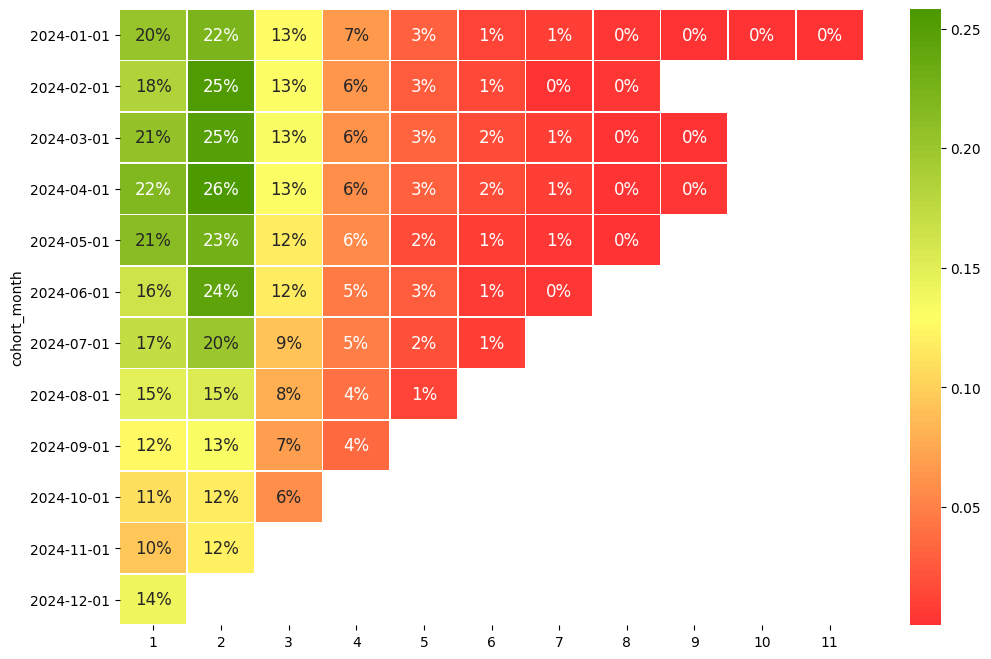

In [44]:
# Считаем конверсию 
cohort_conversion = orders_with_cohort[~orders_with_cohort['total_price'].isna()].groupby(['cohort_month', 'n_month'])['user_id'].nunique() / \
                    orders_with_cohort.groupby('cohort_month')['user_id'].nunique()

# Визуализация
cohort_cr_pivot = cohort_conversion.unstack()


# Форматируем индексы
cohort_cr_pivot.index = pd.to_datetime(cohort_cr_pivot.index).strftime('%Y-%m-%d')



cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100) 


cohort_cr_pivot.columns = [int(col) + 1 for col in cohort_cr_pivot.columns]


# Рисуем тепловую карту
plt.subplots(figsize=(12,8))
sns.heatmap(cohort_cr_pivot,
           cmap=cmap,
           annot=True,
           fmt='.0%',  
           linewidth=0.5,
           annot_kws={"size": 12})
plt.show()

По полученной тепловой карте можно сделать следующие выводы:

1-й месяц: максимальная конверсия (18-22%) наблюдалась в когортах первого полугодия, к сентябрю-декабрю снизилась до 10-14%

2-й месяц: пиковые значения (22-26%) также приходятся на когорты января-июня, к концу года снизились до 12-15%

3-й месяц: в первом полугодии конверсия 12-13%, во втором 6-9%

Через полгода пользователи практически не размещают заказов. 



**Конверсия из регистрации в использование продукта**

Ранее было выяснено, что многие из пользователей после прохождения регистрации не продолжают пользоваться продуктом. Проверим конверсию из регистрации в использование продукта. 

In [45]:
# Добавим основную информацию о клиентах в таблицу с событиями, включая когорту
events_with_cohort=pd.merge(users[['user_id','cohort_month','buyer_segment','region','acq_channel']],events,on='user_id',how='inner')

In [46]:
cr_use=events_with_cohort.groupby('cohort_month')['user_id'].nunique()/users.groupby('cohort_month')['user_id'].nunique()*100

<AxesSubplot:title={'center':'Конверсия из регистрации в использование продукта, %'}, xlabel='Когорта', ylabel='Конверсия'>

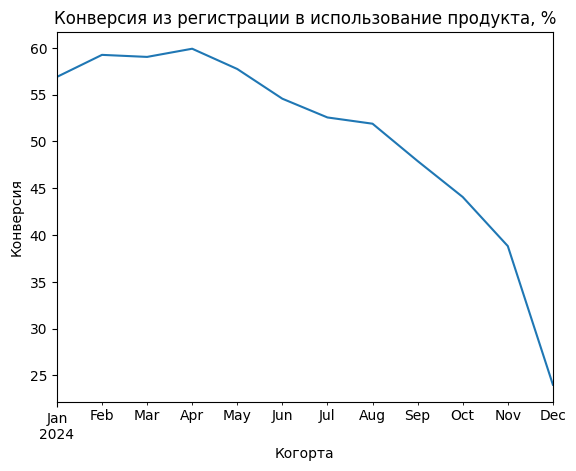

In [47]:
cr_use.plot(kind='line',
                xlabel='Когорта',
                ylabel='Конверсия',
                title='Конверсия из регистрации в использование продукта, %')

Доля пользователей, которые после регистрации переходят к использованию продукта, в первом полугодии 50-60%, а во втором постоянно снижается с 50% в августе до <25% в декабре.

<div style="border:solid pink 5px; padding: 20px">
    <strong>ИНСАЙТ:</strong> Во втором полугодии пользователи существенно реже переходят от регистрации к использованию продукта
</div>

**Revenue**

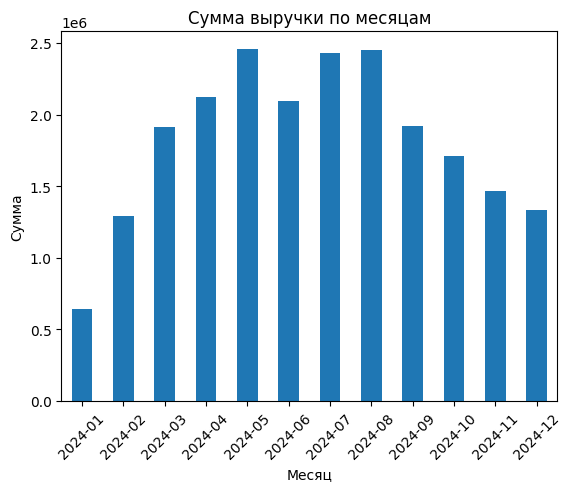

In [48]:
orders['order_month'] = orders['order_month']
revenue=orders.groupby('order_month')['total_price'].sum()*0.05
revenue.index = revenue.index.strftime('%Y-%m') 

revenue.plot(
    kind='bar',
    xlabel='Месяц',
    ylabel='Сумма',
    title='Сумма выручки по месяцам', 
    rot=45
)
plt.show()

По полученной столбчатой диаграмме можем видеть, что с января по май наблюдается рост выручки c 600k до 2500k, затем в течение лета метрика остается примерно одинаковой, а с сентября по декабрь наблюдается плавный спад до 1300k.

**DAU (активные пользователи)**

При расчете DAU будем учитывать только события из датасета `events` (не будем учитывать тех, кто зарегистрировался и потом не заходил).

In [49]:
dau = events.groupby('event_date')['user_id'].nunique()

In [50]:
rolling_avg = dau.rolling(window=7).mean()


In [51]:
dau_df = pd.DataFrame({
    'dau': dau,
    'dau_rolling_avg_7days': rolling_avg
})

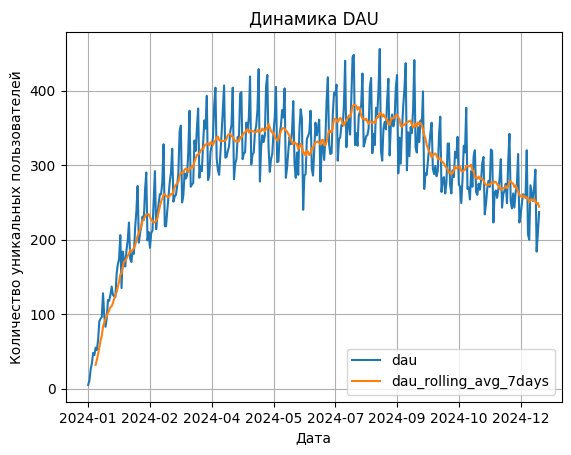

In [52]:
dau_df.index = dau_df.index.strftime('%Y-%m') 

dau_df.plot(
    xlabel='Дата',
    ylabel='Количество уникальных пользователей',
    title='Динамика DAU',
    grid=True
    
)
plt.show()

In [53]:
dau_df.describe()

,dau,dau_rolling_avg_7days
count,366.000000,360.000000
mean,294.322404,297.120238
std,80.626756,68.950005
min,5.000000,32.000000
25%,262.000000,270.714286
50%,307.500000,317.928571
75%,345.000000,345.928571
max,456.000000,381.000000


In [54]:
dau_df.groupby('event_date')['dau'].mean()


event_date
2024-01    104.967742
2024-02    222.758621
2024-03    290.129032
2024-04    331.366667
2024-05    345.612903
2024-06    330.766667
2024-07    348.580645
2024-08    367.645161
2024-09    350.633333
2024-10    299.612903
2024-11    281.533333
2024-12    257.419355
Name: dau, dtype: float64

DAU растет с января (5) по май (350), затем немного спадает в июне (330) и поднимается до 350-367 в июле-сентябре, а у концу года падает до 257 (в декабре). Динамика напоминает динамику суммарной выручки. 

**MAU**

In [55]:
mau_df=events.groupby('event_month')['user_id'].nunique()

<AxesSubplot:title={'center':'Динамика MAU'}, xlabel='Месяц', ylabel='Количество уникальных пользователей'>

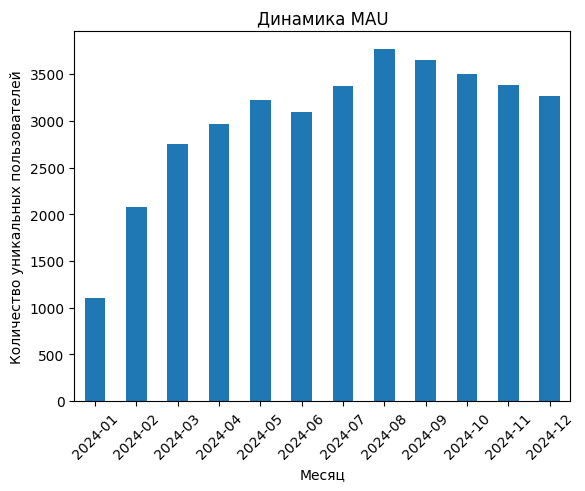

In [56]:
mau_df.index = mau_df.index.strftime('%Y-%m') 

mau_df.plot(
    kind='bar',
    xlabel='Месяц',
    ylabel='Количество уникальных пользователей',
    title='Динамика MAU',
    rot=45
    
)

График изменения MAU демонстрирует рост с 1100 в январе до 3770 в августе (больше, чем в 3 раза), а затем плавный спад до 3250 в декабре. 

**Stickiness**

In [57]:
dau_df=dau_df.reset_index()

In [58]:
dau_df['month']=pd.to_datetime(dau_df['event_date']).dt.to_period('M')

In [59]:
dau_df_avg=dau_df.groupby('month')['dau'].mean()
dau_df_avg.index=dau_df_avg.index.strftime('%Y-%m') 

In [60]:
stickiness_df=pd.DataFrame({'dau_avg':dau_df_avg, 'mau':mau_df})

In [61]:
stickiness_df['stickiness_%']=stickiness_df['dau_avg']/stickiness_df['mau']*100

In [62]:
stickiness_df

,dau_avg,mau,stickiness_%
2024-01,104.967742,1102,9.525203
2024-02,222.758621,2079,10.714700
2024-03,290.129032,2753,10.538650
2024-04,331.366667,2961,11.191039
2024-05,345.612903,3220,10.733320
2024-06,330.766667,3094,10.690584
2024-07,348.580645,3370,10.343639
2024-08,367.645161,3768,9.757037
2024-09,350.633333,3646,9.616932
2024-10,299.612903,3497,8.567712


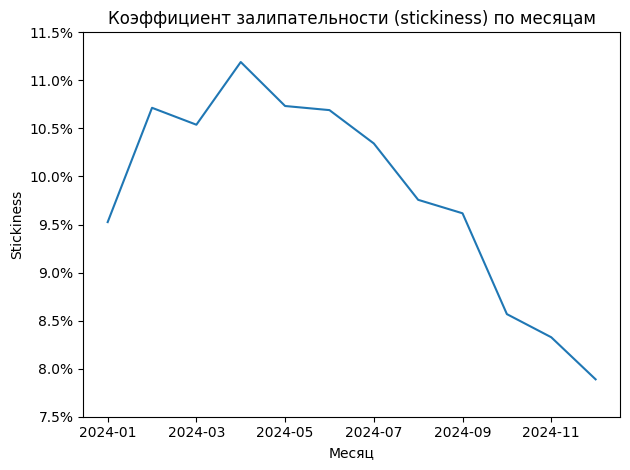

In [63]:
ax=stickiness_df['stickiness_%'].plot(
    xlabel='Месяц',
    ylabel='Stickiness',
    title='Коэффициент залипательности (stickiness) по месяцам'
)
y_ticks = ax.get_yticks()
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{label:.1f}%' for label in ax.get_yticks()])
plt.tight_layout()
plt.show() 

Коэффициент залипательности рос с 9,5% в январе до 11,2% в апреле, а затем равномерно падал до <8% в декабре. Во втором полугодии пользователи стали реже пользоваться продуктом. 

**ARPPU**

In [64]:
orders_by_users_monthly=orders.groupby(['user_id','order_month'])['total_price'].sum().reset_index()

In [65]:
arppu=orders_by_users_monthly.groupby('order_month')['total_price'].sum()*0.05/orders_by_users_monthly.groupby('order_month')['user_id'].nunique()

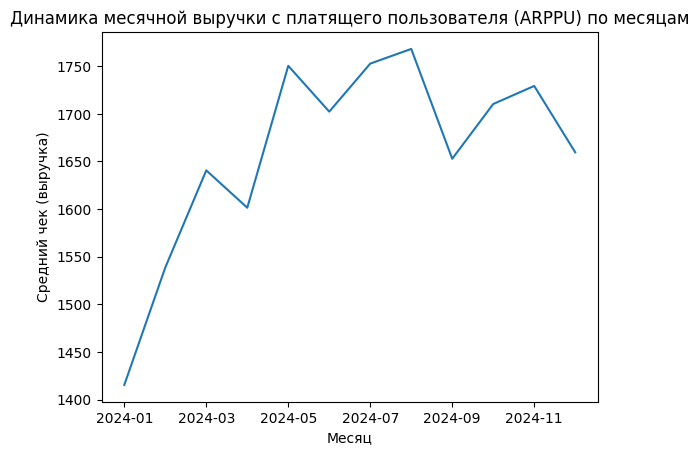

In [66]:
arppu.index = arppu.index.strftime('%Y-%m') 

arppu.plot(
    xlabel='Месяц',
    ylabel='Средний чек (выручка)',
    title='Динамика месячной выручки с платящего пользователя (ARPPU) по месяцам'
)
plt.show()

In [67]:
arppu

order_month
2024-01    1415.553109
2024-02    1538.741151
2024-03    1640.635353
2024-04    1601.455971
2024-05    1750.327689
2024-06    1702.247294
2024-07    1752.642996
2024-08    1768.057642
2024-09    1652.820175
2024-10    1710.250120
2024-11    1729.211214
2024-12    1659.600727
dtype: float64

По графику наблюдаем рост месячной выручки с платящего пользователя с января (1400) по май (1750), затем в июне-августе значение составляет 1700-1770, а в сентябре-декабре небольшой спад до 1650-1700.

**ARPU**

In [68]:
arpu=orders_by_users_monthly.groupby('order_month')['total_price'].sum()*0.05/events.groupby('event_month')['user_id'].nunique()

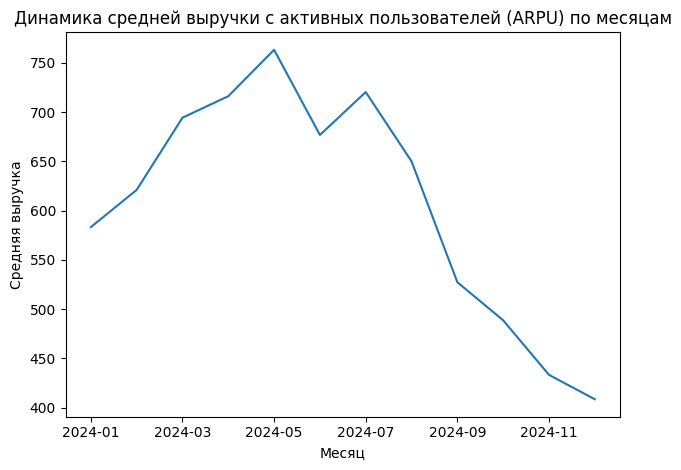

In [69]:
arpu.index = arpu.index.strftime('%Y-%m') 

arpu.plot(
    xlabel='Месяц',
    ylabel='Средняя выручка',
    title='Динамика средней выручки с активных пользователей (ARPU) по месяцам'
)
plt.tight_layout()
plt.show()

По графику виден сначала рост ARPU с января (580) по май (760), а затем быстрое падение к концу года (до 400). Аудитория продукта растет, однако, многие из пользователей не совершают покупок, из-за чего средняя выручка с пользователя падает практически в 2 раза относительно максимума в мае. 

<div style="border:solid pink 5px; padding: 20px">
    <strong>ИНСАЙТ:</strong> Выручка с платящих пользователей существенно не убывает, но падает выручка с активных пользователей - Аудитория продукта растет, но многие из новых пользователей не совершают покупок, хотя и пользуются продуктом.
</div>

**AOV**

In [70]:
aov=orders.groupby('order_month')['total_price'].sum()/orders.groupby('order_month')['order_id'].nunique()

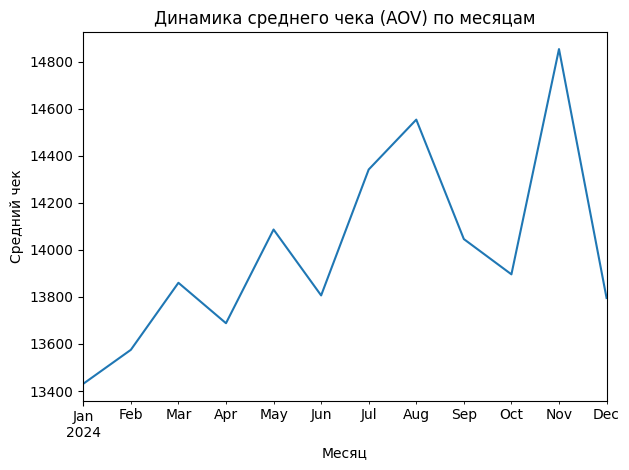

In [71]:
aov.plot(
    xlabel='Месяц',
    ylabel='Средний чек',
    title='Динамика среднего чека (AOV) по месяцам'
)
plt.tight_layout()
plt.show()

По графику AOV наблюдаются колебания в пределах 10% в величине средней суммы заказа в течение года - от 13430 в январе (минимум) до 14850 в ноябре, самые высокие значения среднего чека - в июле, августе и ноябре. Самые низкие - в январе, октябре, декабре. В целом, можно говорить об относительной стабильности метрики. 

**Retention Rate**

Таблица `events` содержит информацию о действиях пользователей (и не содержит информации о датах их регистрации). Для расчета Retention добавим данные о когорте из `users`. 

Для расчета Retention будем рассматривать возвращаемость всех зарегистрированных пользователей.

In [72]:
cohort_data = users[['user_id', 'cohort_month','cohort_week','acq_channel','region','buyer_segment']]
cohort_data['n_month'] = 0
cohort_data['n_week'] = 0

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17720\1932062558.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cohort_data['n_month'] = 0
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17720\1932062558.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cohort_data['n_week'] = 0


In [73]:
activity_data = pd.merge(
    users[['user_id', 'cohort_month','cohort_week']],
    events[['user_id', 'event_month','event_week']], 
    on='user_id', 
    how='left'
)

In [74]:
#Проверяем количество пользователей в объединенном датафрейме
activity_data['user_id'].nunique()

44151

В полученном датасете к информации о месяце пользовательских событий была добавлена информация о когорте (месяц регистрации в продукте).

In [75]:
activity_data['n_month'] = activity_data['event_month'].dt.month - activity_data['cohort_month'].dt.month


In [76]:
#Вычисляем номер месяца жизненного цикла пользователя
activity_data['n_month'].unique()

array([nan,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  9., 10., 11.,  7.,  8.])

nan-значения соответствуют пользователям, которые прошли регистрацию, но после этого не взаимодействовали с продуктом.

In [77]:
all_activity = pd.concat([
    cohort_data[['user_id', 'cohort_month', 'n_month']],
    activity_data[['user_id', 'cohort_month', 'n_month']]
], ignore_index=True)

In [78]:
cohort_activity = all_activity.groupby(['cohort_month', 'n_month'])['user_id'].nunique().unstack()


In [79]:
cohort_activity

n_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0
cohort_month,,,,,,,,,,,,
2024-01-01,2985.0,1102.0,529.0,244.0,123.0,55.0,26.0,12.0,1.0,2.0,1.0,1.0
2024-02-01,2711.0,1098.0,485.0,245.0,128.0,50.0,24.0,10.0,3.0,1.0,2.0,NaN
2024-03-01,2965.0,1115.0,568.0,275.0,127.0,62.0,24.0,8.0,2.0,2.0,NaN,NaN
2024-04-01,2905.0,1142.0,563.0,272.0,140.0,66.0,31.0,20.0,9.0,NaN,NaN,NaN
2024-05-01,3066.0,1132.0,527.0,237.0,111.0,50.0,14.0,7.0,NaN,NaN,NaN,NaN
2024-06-01,2810.0,964.0,478.0,214.0,106.0,50.0,15.0,NaN,NaN,NaN,NaN,NaN
2024-07-01,4388.0,1437.0,653.0,311.0,156.0,56.0,NaN,NaN,NaN,NaN,NaN,NaN
2024-08-01,4431.0,1337.0,629.0,330.0,145.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-01,4466.0,1274.0,623.0,255.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<AxesSubplot:ylabel='cohort_month'>

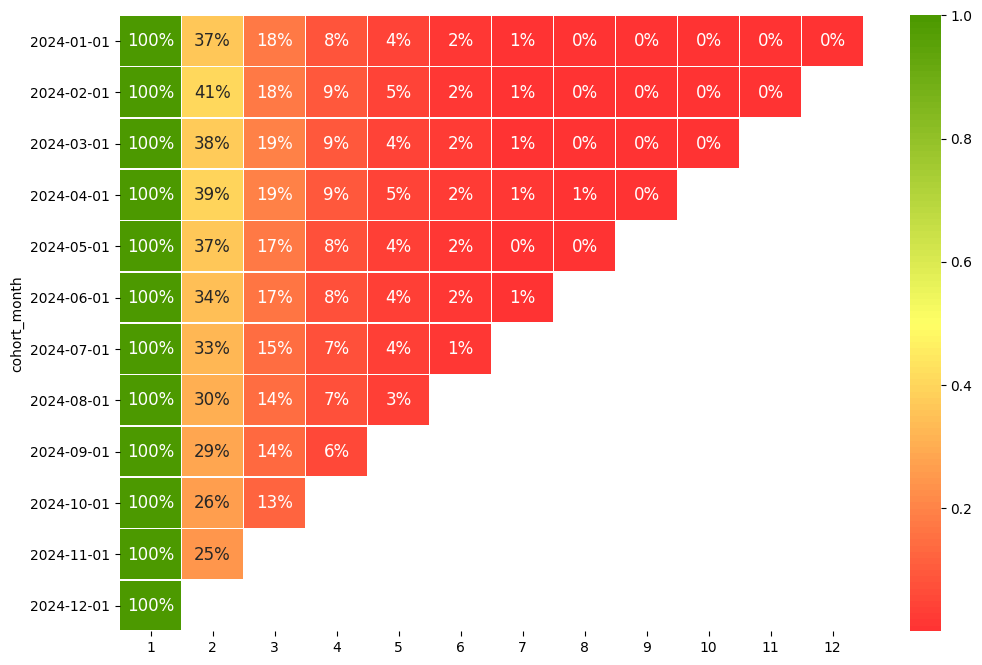

In [80]:
# Получаем общее количество пользователей в каждой когорте (месяц 0)
cohort_size = activity_data.groupby('cohort_month')['user_id'].nunique()

# Нормализуем по размеру когорты
cohort_retention = cohort_activity.div(cohort_size, axis=0)

# # Меняем названия столбцов для отображения
cohort_retention.columns = [int(col)+1 for col in cohort_retention.columns]
cohort_retention.index = pd.to_datetime(cohort_retention.index).strftime('%Y-%m-%d')

cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100) 


plt.subplots(figsize=(12,8))


sns.heatmap(cohort_retention,
           cmap=cmap,
           annot=True,
           fmt='.0%',
           linewidth=0.5,
           annot_kws={"size": 12})

По полученной тепловой карте можем видеть, что возвращаемость пользователей в продукт уже на второй месяц после регистрации не превышает 41%, к 5 месяцу составляет около 5%, а к 7 месяцу - только 1%. Также заметно дополнительное падение Retention, начиная с июньской когорты, а к ноябрю Retention Rate через месяц после регистрации составляет уже всего 25%. Каждые 3 из 4 из привлеченных в ноябре пользователей не вернулись в продукт через месяц после регистрации. 

### 3. Оценка метрик монетизации и юнит-экономики

Рассчитаем метрики монетизации двумя способами - учитывая всех пользователей и только активных. 

### Юнит-экономика по всем пользователям

In [81]:
#Средняя стоимость привлечения клиента (за 2024 год)
cac_total=campaign_costs['budget'].sum()/users['user_id'].nunique()
round(cac_total)

402

In [82]:
#Средняя выручка с клиента (за 2024 год)
ltv_total=orders['total_price'].sum()*0.05/users['user_id'].nunique()
round(ltv_total)

494

In [83]:
#Окупаемость вложений за 2024 год
roi_total=round((ltv_total-cac_total)/cac_total*100)
roi_total

23

Средняя стоимость привлечения клиента составляет 402, а средняя выручка с клиента - 494. Окупаемость вложений составляет 23%. Рассмотрим динамику показателей по месяцам. 

In [84]:
cac=campaign_costs.groupby('spend_month')['budget'].sum()/users.groupby('cohort_month')['user_id'].nunique()

In [85]:
ltv=orders_with_cohort.groupby('cohort_month')['total_price'].sum()*0.05/users.groupby('cohort_month')['user_id'].nunique()

In [86]:
cac.index = cac.index.strftime('%Y-%m')
ltv.index = ltv.index.strftime('%Y-%m')

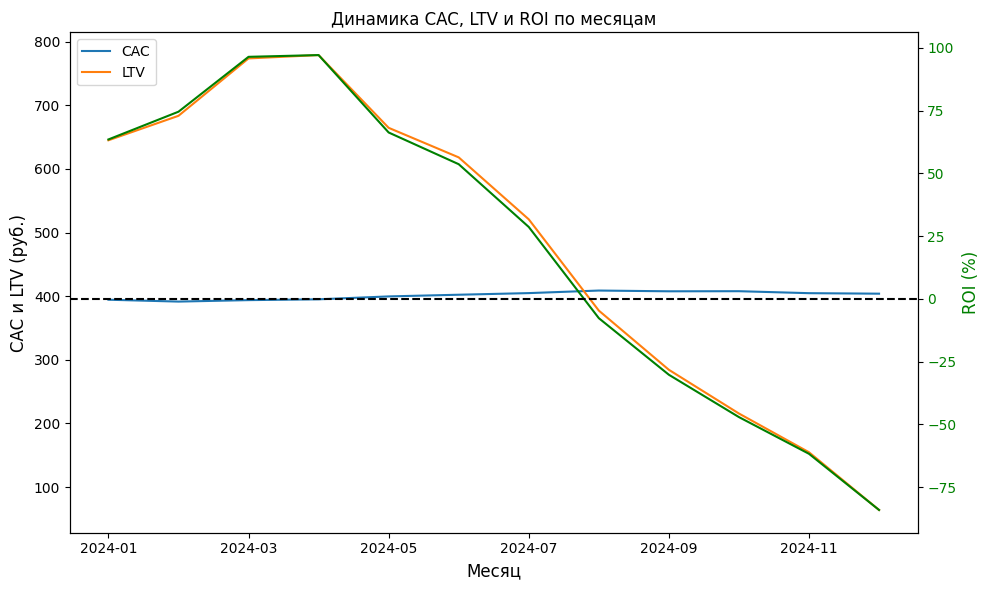

In [87]:
unit_metrics = pd.DataFrame({
    'CAC': cac,
    'LTV': ltv
})

unit_metrics['ROI'] = (unit_metrics['LTV'] - unit_metrics['CAC']) / unit_metrics['CAC']

fig, ax1 = plt.subplots(figsize=(10, 6))

# Левая ось
unit_metrics[['CAC', 'LTV']].plot(ax=ax1)
ax1.set_xlabel('Месяц', fontsize=12)
ax1.set_ylabel('CAC и LTV (руб.)', fontsize=12)
ax1.legend(loc='upper left')

# Правая ось
ax2 = ax1.twinx()
(unit_metrics['ROI'] * 100).plot(ax=ax2, color='green')
ax2.set_ylabel('ROI (%)', fontsize=12, color='green')
ax2.axhline(y=0, color='black', linestyle='--')
ax2.tick_params(axis='y', labelcolor='green')

# Настройки
plt.xticks(rotation=45, ha='right')
plt.title('Динамика CAC, LTV и ROI по месяцам')

plt.tight_layout()
plt.show()


По графику можно отметить, что величина CAC практически не меняется, поэтому график ROI повторяет график LTV. Продукт окупается в период с января по июль, а затем становится убыточен. На привлечение пользователей тратятся средства, пользователи прибывают, но по какой-то причине не становятся покупателями. Максимальная окупаемость - в апреле (+100%), максимальная убыточность - в декабре (-85%).

**Период окупаемости (Payback Period)**

In [88]:
#Рассчитаем накопленный LTV по когортам и месяцам
revenue_by_cohort = orders_with_cohort.groupby(['cohort_month', 'n_month'])['total_price'].sum() * 0.05
cumulative_ltv = (revenue_by_cohort.groupby(level=0).cumsum()/ cohort_size).unstack()

In [89]:
cac.index = cac.index.astype(str)  
cumulative_ltv.index = cumulative_ltv.index.strftime('%Y-%m')  

payback_results = []
for cohort in cumulative_ltv.index:
    cac_value = cac[cohort]
    ltv_by_month = cumulative_ltv.loc[cohort]
    
    payback_month = None
    for month in ltv_by_month.index:
        if ltv_by_month[month] >= cac_value:
            payback_month = month
            break
    
    payback_results.append({
        'cohort': cohort,  # убрали .strftime('%Y-%m')
        'CAC': round(cac_value, 0),
        'payback_month': payback_month,
        'status': 'Окупилась' if payback_month else 'Не окупилась'
    })

# Создаем DataFrame с результатами
payback_df = pd.DataFrame(payback_results)


In [90]:
payback_df

,cohort,CAC,payback_month,status
0,2024-01,394.0,2.0,Окупилась
1,2024-02,392.0,1.0,Окупилась
2,2024-03,394.0,1.0,Окупилась
3,2024-04,395.0,1.0,Окупилась
4,2024-05,400.0,1.0,Окупилась
5,2024-06,402.0,1.0,Окупилась
6,2024-07,405.0,2.0,Окупилась
7,2024-08,409.0,NaN,Не окупилась
8,2024-09,408.0,NaN,Не окупилась
9,2024-10,408.0,NaN,Не окупилась


In [91]:
cumulative_ltv.div(cac,axis=0)-1

n_month,0,1,2,3,4,5,6,7,8,9,10
cohort_month,,,,,,,,,,,
2024-01,-0.572174,-0.032179,0.316308,0.441758,0.571914,0.596822,0.616183,0.633664,0.634080,0.634611,0.635116
2024-02,-0.584271,0.110008,0.449263,0.597084,0.677107,0.705110,0.728761,0.745645,NaN,NaN,NaN
2024-03,-0.523897,0.148571,0.552405,0.754545,0.855018,0.906398,0.954738,0.958209,0.964383,NaN,NaN
2024-04,-0.465051,0.234521,0.574287,0.758028,0.842121,0.910441,0.951498,0.956449,0.971357,NaN,NaN
2024-05,-0.496209,0.122104,0.439724,0.595982,0.628634,0.645570,0.659826,0.662861,NaN,NaN,NaN
2024-06,-0.658630,0.019886,0.332875,0.454354,0.516882,0.531821,0.536480,NaN,NaN,NaN,NaN
2024-07,-0.637548,-0.126751,0.093763,0.213807,0.259951,0.286327,NaN,NaN,NaN,NaN,NaN
2024-08,-0.707165,-0.375092,-0.187251,-0.104375,-0.077073,NaN,NaN,NaN,NaN,NaN,NaN
2024-09,-0.783811,-0.512188,-0.369249,-0.302579,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Юнит-экономика по активным пользователям

In [92]:
#Затраты на привлечение активных пользователей
cac_total_active=campaign_costs['budget'].sum()/events['user_id'].nunique()
round(cac_total_active)

822

In [93]:
#Выручка с активных пользователей
ltv_total_active=orders['total_price'].sum()*0.05/events['user_id'].nunique()
round(ltv_total_active)

1010

In [94]:
#Окупаемость вложений (по активным пользователям)
roi_total_active=(ltv_total_active-cac_total_active)/cac_total_active*100
round(roi_total_active)

23

Значение ROI активных пользователей совпадает с ROI по всем пользователям. Проверим динамику по месяцам.

In [95]:
cac_active=campaign_costs.groupby('spend_month')['budget'].sum()/events_with_cohort.groupby('cohort_month')['user_id'].nunique()
round(cac_active)

spend_month
2024-01-01     693.0
2024-02-01     661.0
2024-03-01     667.0
2024-04-01     660.0
2024-05-01     692.0
2024-06-01     737.0
2024-07-01     770.0
2024-08-01     788.0
2024-09-01     851.0
2024-10-01     926.0
2024-11-01    1043.0
2024-12-01    1683.0
dtype: float64

In [96]:
ltv_active=orders_with_cohort.groupby('cohort_month')['total_price'].sum()*0.05/events_with_cohort.groupby('cohort_month')['user_id'].nunique()

In [97]:
cac_active.index = cac_active.index.strftime('%Y-%m')
ltv_active.index = ltv_active.index.strftime('%Y-%m')

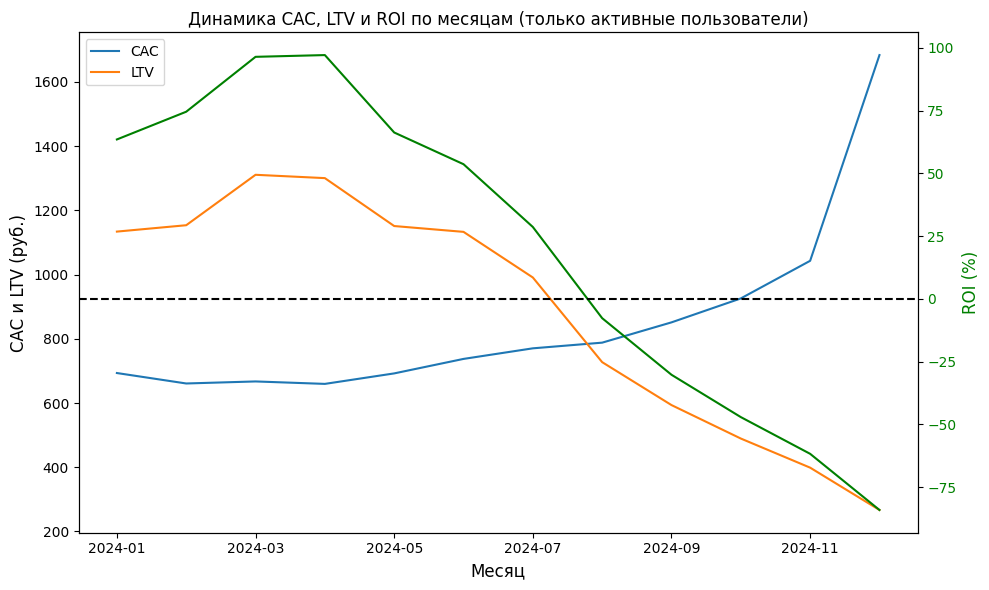

In [98]:
unit_metrics_active = pd.DataFrame({
    'CAC': cac_active,
    'LTV': ltv_active
})

unit_metrics_active['ROI'] = (unit_metrics_active['LTV'] - unit_metrics_active['CAC']) / unit_metrics_active['CAC']

fig, ax1 = plt.subplots(figsize=(10, 6))

# Левая ось
unit_metrics_active[['CAC', 'LTV']].plot(ax=ax1)
ax1.set_xlabel('Месяц', fontsize=12)
ax1.set_ylabel('CAC и LTV (руб.)', fontsize=12)
ax1.legend(loc='upper left')

# Правая ось
ax2 = ax1.twinx()
(unit_metrics_active['ROI'] * 100).plot(ax=ax2, color='green')
ax2.set_ylabel('ROI (%)', fontsize=12, color='green')
ax2.axhline(y=0, color='black', linestyle='--')
ax2.tick_params(axis='y', labelcolor='green')

# Настройки
plt.xticks(rotation=45, ha='right')
plt.title('Динамика CAC, LTV и ROI по месяцам (только активные пользователи)')

plt.tight_layout()
plt.show()


По графику можно отметить, что до июля продукт находился в зоне окупаемости (максимум +100% в марте-апреле), а после июля стал убыточен (до -85% в декабре). Это связано с тем, что стоимость привлечения **активных** пользователей во втором полугодии выросла, а выручка упала. Можно сделать предположение, что маркетинговые траты распределены неоптимальным образом, и в продукт привлекается некачественный трафик (пользователи не пользуются продуктом и не становятся покупателями). 

## Предварительные выводы


**Ключевые точки оттока в воронке:**

- Этап "начало использования приложения": теряется более 50% пользователей после регистрации

- Этап "оплата заказа": теряется 33% пользователей, начавших оформление

- Итоговая конверсия в платящего пользователя: всего немного выше 20%

**Конверсия из регистрации в использование продукта:**

- Первое полугодие: 50-60%

- Второе полугодие: падение с 50% (август) до менее 25% (декабрь)



Продукт демонстрирует ярко выраженную сезонность с пиком активности в мае и спадом во втором полугодии 2024 года.

- **Выручка**: Рост с января по май (максимум в мае), стабилизация летом, спад с сентября по декабрь

- **Активность пользователей (DAU, MAU)**: Динамика повторяет выручку: рост до мая, спад с сентября

- **Stickiness** (коэффициент залипательности): Рост с января по апрель 9.5% -> 11.2%, затем плавное падение до <8% в декабре

**! Тревожный сигнал**: начиная с мая пользователи стали реже пользоваться продуктом

- **ARPPU** (выручка с платящего пользователя): Рост с января по май, небольшой спад в конце года, платящие пользователи продолжают тратить стабильно

- **ARPU** (выручка со всех пользователей): Рост до мая, затем резкое падение к декабрю (снижение в 2 раза относительно максимума)

**! Тревожный сигнал**: аудитория растет, но большая часть новых пользователей не совершает покупки

- **AOV (средний чек)**: Относительная стабильность в течение года (колебания ±10%), максимальные значения в июле, августе, ноябре (до 14 850 руб.), минимальные в январе, октябре, декабре (от 13 430 руб.)

- **Retention Rate** (возвращаемость): Уже на 2-й месяц retention не превышает 41%, к 5-му месяцу падает до 5%, к 7-му — до 1%

- **Conversion Rate** (конверсия в заказ): 1-й месяц: 18-22% (январь-июнь) → снижение до 10-14% (сентябрь-декабрь), 2-й месяц: 22-26% (январь-июнь) → снижение до 12-15%, 3-й месяц: 12-13% → снижение до 6-9 %, Через полгода — практически не размещают заказов. 


#### Юнит-экономика:

**Все зарегистрированные пользователи:**
- CAC стабилен (~400 руб.) на протяжении всего года

- LTV повторяет сезонность продукта: рост до мая, спад с сентября

- ROI положительный с января по июль (максимум +100% в апреле). С августа ROI становится отрицательным, достигая -85% в декабре

**Активные пользователи:**
- CAC растет во втором полугодии с 800 до 1 200 руб.

- LTV падает с максимума 2 000 руб. в апреле до 300 руб. в декабре

- ROI положительный до июля (максимум +100% в марте-апреле)

- С августа ROI отрицательный, падая до -85% в декабре

- До июля период окупаемости 1-2 месяца, начиная с августа привлечение пользователей не окупается



#### Основные проблемы продукта:

- Более половины пользователей не начали использовать продукт после регистрации, из оставшихся треть теряется на этапе оплаты.

- Падение качества трафика во втором полугодии, рост аудитории не сопровождается ростом выручки (ARPU падает)

- Низкая возвращаемость пользователей (Retention <25% на 2-й месяц в конце года)

- Снижение конверсии в заказ во всех когортах второго полугодия

- Убыточность привлечения с августа

- Растет доля неактивных пользователей (к концу года - более 75% зарегистрировавшихся пользователей не начинают использовать продукт)



## 4. Поиск инсайтов, точек роста и сегментация


#### Построение пользовательской воронки

Рассчитаем пользовательскую воронку в классическом варианте и step-by-step.

In [99]:
#Выведем уникальные события, выделим из них важные для анализа покупательской активности пользователей

events.groupby('event_type')['user_id'].nunique().sort_values(ascending=False)

event_type
page_view            21562
product_view         21533
product_click        21211
add_to_cart          19887
checkout_start       16293
checkout_complete    13486
filter_apply          8196
user_login            8147
category_view         8137
search                8030
user_logout           8028
banner_click          8017
remove_from_cart      8005
promo_view            8004
wishlist_add          7901
Name: user_id, dtype: int64

In [100]:
events['user_id'].nunique()

21602

Согласно описанию данных, событие `checkout_complete` - это завершение оформления заказа (не гарантирует покупку, покупка зависит от факта оплаты).
Поэтому в воронку необходимо будет добавить событие `payment_success`, которое будет отражать факт оплаты пользователем заказа. 


In [101]:
#Рассчитаем количество пользователей, которые разместили (оплатили заказ)
orders['user_id'].nunique()

8922

Действительно, уже сейчас можно отметить, что многие пользователи не завершают процесс оплаты.

Воронку будем смотреть по следующим этапам из датасета `events` - просмотр продукта, добавление в корзину, начало оформления и завершение оформления заказа. Затем добавим факт регистрации, любого действия в приложении и факт размещенного заказа. 

In [102]:
funnel_steps=[
    'product_view',
    'add_to_cart',
    'checkout_start',
    'checkout_complete'
]

In [103]:
funnel_list = []

for step in funnel_steps:
    user_count = events[events['event_type'] == step]['user_id'].nunique()
    funnel_list.append(user_count)

funnel_list=[users['user_id'].nunique()]+[events['user_id'].nunique()]+funnel_list
funnel_steps=['registration']+['app_open']+funnel_steps
funnel_list.append(orders['user_id'].nunique())
funnel_steps.append('payment_success')


funnel_df = pd.Series(funnel_list, index=funnel_steps)
funnel_classic = (funnel_df/ funnel_df.iloc[0] * 100).round(2)


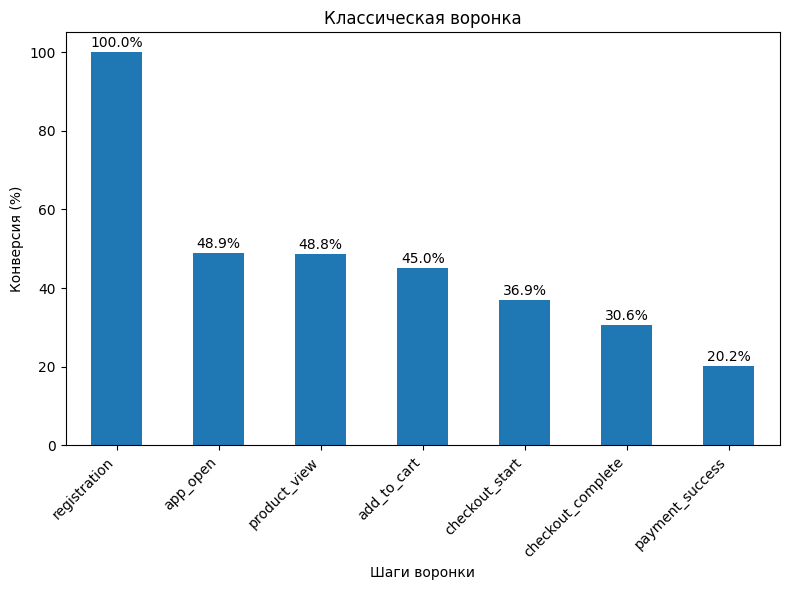

In [104]:
ax=funnel_classic.plot(
    kind='bar',
    xlabel='Шаги воронки',
    ylabel='Конверсия (%)',
    rot=45,
    figsize=(8,6)
)
for i, v in enumerate(funnel_classic.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom')

plt.xticks(ha='right')
plt.title('Классическая воронка')
plt.tight_layout()
plt.show()

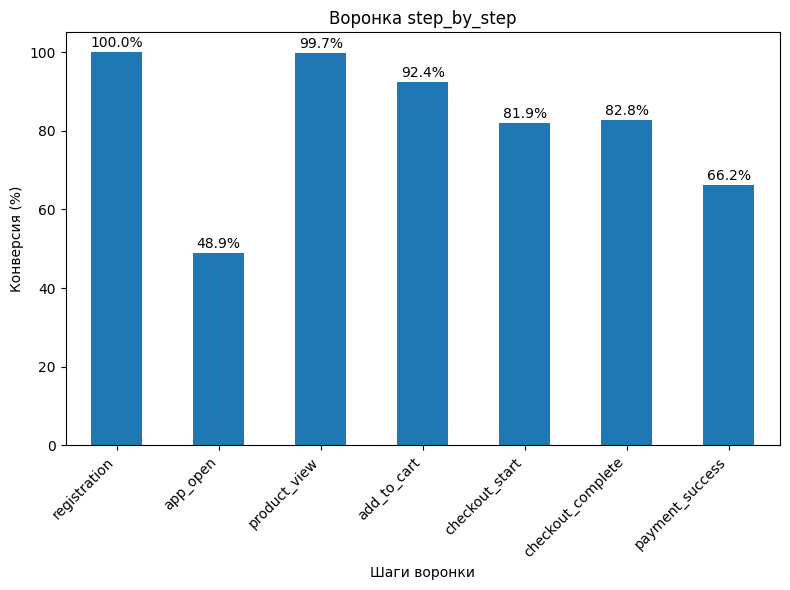

In [105]:
funnel_step_by_step = (funnel_df / funnel_df.shift(1) * 100).round(2)
#Заполним пропуск для первого шага
funnel_step_by_step.iloc[0] = 100.0

ax=funnel_step_by_step.plot(
    kind='bar',
    xlabel='Шаги воронки',
    ylabel='Конверсия (%)',
    rot=45,
    figsize=(8,6)
)
for i, v in enumerate(funnel_step_by_step.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom')

plt.xticks(ha='right')
plt.title('Воронка step_by_step')
plt.tight_layout()
plt.show()

Больше всего пользователей (>50%) теряются на этапе начала использования приложением, также большие потери пользователей (33%) - на этапе осуществления оплаты. Помимо этого, почти по 20% теряется последовательно на этапах начала оформления и завершения оформления заказа. Итоговая конверсия - немного выше 20%.

#### Сегментация метрик по каналу привлечения

В предыдущем разделе было обнаружено, что продукт перестал окупаться во втором полугодии. Это может быть связано с неоптимальными затратами на привлечение пользователей. Рассмотрим динамику маркетинговых трат (суммарную) и распределение трат по каналам. 

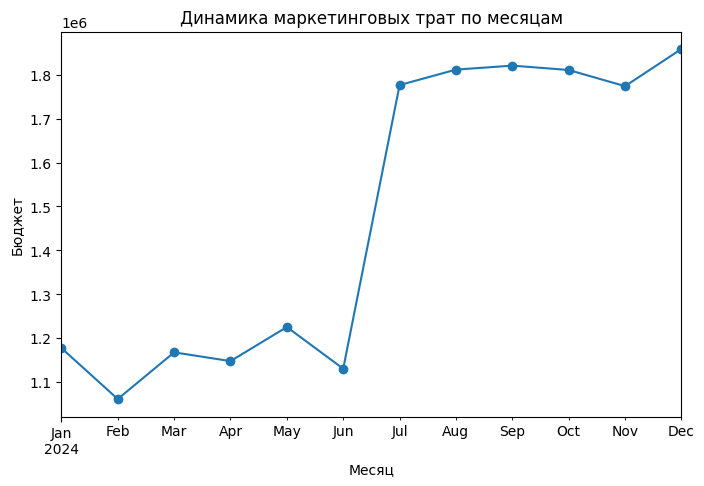

In [106]:
total_costs=campaign_costs.groupby('spend_month')['budget'].sum()
total_costs.plot(
    kind='line',
    xlabel='Месяц',
    ylabel='Бюджет',
    title='Динамика маркетинговых трат по месяцам',
    figsize=(8,5),
    marker='o'
)
plt.show()

In [107]:
total_costs

spend_month
2024-01-01    1.177457e+06
2024-02-01    1.061386e+06
2024-03-01    1.167680e+06
2024-04-01    1.147740e+06
2024-05-01    1.225322e+06
2024-06-01    1.130440e+06
2024-07-01    1.776447e+06
2024-08-01    1.811678e+06
2024-09-01    1.820719e+06
2024-10-01    1.810803e+06
2024-11-01    1.773970e+06
2024-12-01    1.858570e+06
Name: budget, dtype: float64

По графику видим, что с июля в 1,5+ раза возросли расходы на рекламу - в начале года они составляли 1.1-1.2 млн, а начиная с июля общий бюджет вырос до ~1.8 млн.

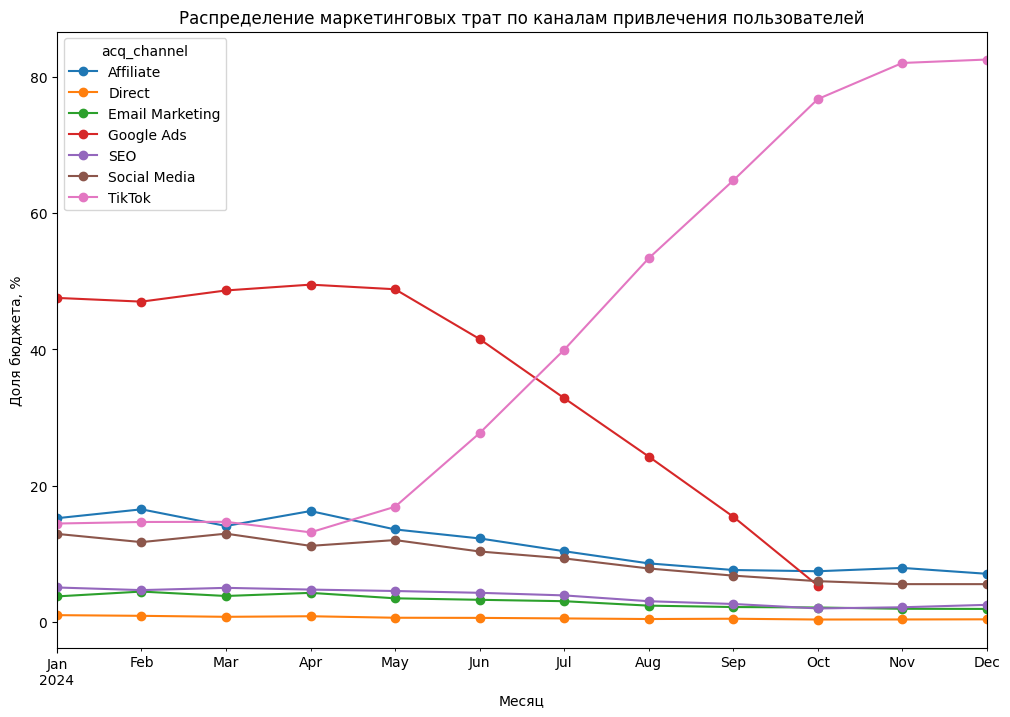

In [108]:
costs_pivot=campaign_costs.pivot(index='spend_month',columns='acq_channel',values='budget').div(total_costs,axis=0)*100
costs_pivot.plot(
    kind='line',
    xlabel='Месяц',
    ylabel='Доля бюджета, %',
    title='Распределение маркетинговых трат по каналам привлечения пользователей',
    figsize=(12,8),
    marker='o'
)
plt.show()

<div style="border:solid pink 5px; padding: 20px">
    <strong>ИНСАЙТ:</strong> Проблемы с окупаемостью могут быть связаны с перераспределением маркетинговых трат в пользу TikTok - с июня траты на него начали расти и с июля преобладают над остальными, а к ноябрю-декабрю составляют 80% всего маркетингового бюджета.

</div>

**Количество привлеченных пользователей по каналам привлечения**

In [109]:
users_by_channel=users.groupby(['cohort_month','acq_channel'])['user_id'].nunique().unstack()

In [110]:
users.groupby('cohort_month')['user_id'].nunique()

cohort_month
2024-01-01    2985
2024-02-01    2711
2024-03-01    2965
2024-04-01    2905
2024-05-01    3066
2024-06-01    2810
2024-07-01    4388
2024-08-01    4431
2024-09-01    4466
2024-10-01    4440
2024-11-01    4383
2024-12-01    4601
Name: user_id, dtype: int64

<AxesSubplot:xlabel='acq_channel', ylabel='cohort_month'>

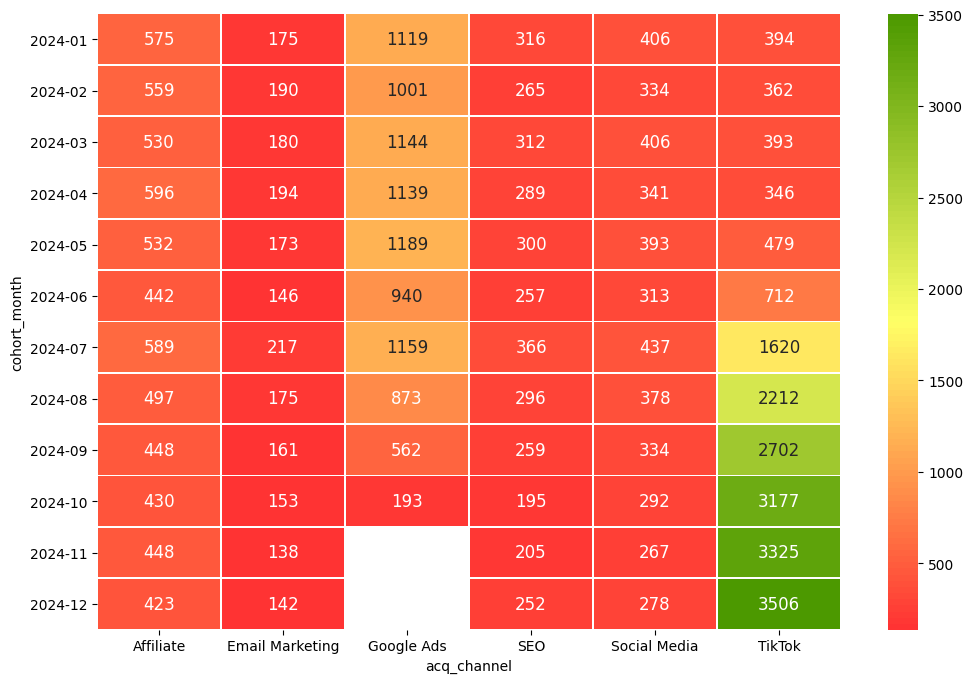

In [111]:
# Форматируем индексы
users_by_channel.index = pd.to_datetime(users_by_channel.index).strftime('%Y-%m')

cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100) 

# Рисуем тепловую карту
plt.subplots(figsize=(12,8))
sns.heatmap(users_by_channel,
           cmap=cmap,
           annot=True,
           fmt='.0f',  
           linewidth=0.5,
           annot_kws={"size": 12})

<div style="border:solid pink 5px; padding: 20px">
    <strong>ИНСАЙТ:</strong> По тепловой карте можно отметить, что во втором полугодии существенно изменилось распределение пользователей по каналам привлечения: доля пользователей, привлеченных через TikTok существенно возрастает, а доля пользователей, привлеченных через другие каналы снижается. В этот же период отмечается снижение монетизации продукта. Вероятно, через TikTok привлекается некачественный трафик - пользователи регистрируются, но в дальнейшем не пользуются продуктом и не совершают заказов.
</div>



**Продуктовая воронка по каналам привлечения**

In [112]:
funnel_steps=[
    'product_view',
    'add_to_cart',
    'checkout_start',
    'checkout_complete'
]

In [113]:
orders

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month,delta
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,0.0
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,0.0
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01,0.0
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01,0.0
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01,0.0
...,...,...,...,...,...,...,...,...,...,...,...
31082,31774,44719,2024-12-30 02:21:00,Дезодорант,2,697.72,1395.44,Средства для ухода,2024-12-30,2024-12-01,0.0
31083,31775,44719,2024-12-30 02:21:00,Поло Ralph Lauren,2,5446.69,10893.38,Мужская одежда,2024-12-30,2024-12-01,0.0
31084,31776,44777,2024-12-30 17:45:00,Футболка дышащая,1,3114.57,3114.57,Одежда для спорта,2024-12-30,2024-12-01,0.0
31085,31777,44777,2024-12-30 17:45:00,Костюм спортивный,2,6999.82,13999.64,Одежда для спорта,2024-12-30,2024-12-01,0.0


In [114]:
users[users['acq_channel']=='Email Marketing']['user_id'].nunique()

2044

In [115]:
orders_with_cohort

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month,order_id,order_month,total_price,category_name,n_month
0,2,2024-01-01 19:01:00,53,M,Москва,Email Marketing,rare,2024-01-01,2024-01-01,NaN,NaT,NaN,NaN,0
1,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01,1.0,2024-01-01,11078.26,Инструменты и садовый инвентарь,0
2,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01,2.0,2024-01-01,11340.38,Инструменты и садовый инвентарь,0
3,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01,3.0,2024-01-01,21784.18,Инструменты и садовый инвентарь,0
4,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01,4.0,2024-01-01,11078.26,Инструменты и садовый инвентарь,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41859,44749,2024-12-30 17:15:00,55,F,Москва,Affiliate,regular,2024-12-30,2024-12-01,NaN,NaT,NaN,NaN,0
41860,44751,2024-12-30 21:24:00,66,F,Другие регионы,TikTok,medium,2024-12-30,2024-12-01,NaN,NaT,NaN,NaN,0
41861,44783,2024-12-30 09:25:00,68,M,Другие регионы,TikTok,one_time,2024-12-30,2024-12-01,NaN,NaT,NaN,NaN,0
41862,44808,2024-12-31 12:52:00,19,F,Москва,Email Marketing,medium,2024-12-30,2024-12-01,NaN,NaT,NaN,NaN,0


In [116]:
events_with_cohort[events_with_cohort['acq_channel'] == 'Email Marketing']['user_id'].nunique()

1272

In [117]:
def build_funnel(events_data, users_data, orders_data, segment_column='acq_channel'):
    """
    Построение классической и пошаговой воронки для заданных срезов    
    
    Parameters:
    -----------
    users_data : DataFrame
        Данные пользователей (должны содержать user_id и segment_column)
    events_data : DataFrame
        Данные событий (должны содержать user_id, event_type и segment_column)
    orders_data : DataFrame
        Данные заказов (должны содержать user_id, order_id и segment_column)
    segment_column : str
        Название колонки с сегментом (каналом)
    
    Returns:
    --------
    funnel_classic_segment, funnel_step_segment : DataFrames
        DataFrames с конверсиями по сегментам
    """

    channels = sorted(users_data[segment_column].unique())
    
    funnel_steps = ['registration', 'app_open', 'product_view', 'add_to_cart', 
                    'checkout_start', 'checkout_complete', 'payment_success']

    results_classic = {}
    results_step = {}

    for channel in channels:
        users_ch = users_data[users_data[segment_column] == channel]
        events_ch = events_data[events_data[segment_column] == channel]
        orders_ch = orders_data[(orders_data[segment_column] == channel) & 
                                 (orders_data['order_id'].notna())]
        
        counts = []
        counts.append(users_ch['user_id'].nunique())  # registration
        counts.append(events_ch['user_id'].nunique())  # app_open
        counts.append(events_ch[events_ch['event_type'] == 'product_view']['user_id'].nunique())
        counts.append(events_ch[events_ch['event_type'] == 'add_to_cart']['user_id'].nunique())
        counts.append(events_ch[events_ch['event_type'] == 'checkout_start']['user_id'].nunique())
        counts.append(events_ch[events_ch['event_type'] == 'checkout_complete']['user_id'].nunique())
        counts.append(orders_ch['user_id'].nunique())  # payment_success
        
        # Классическая конверсия
        classic_conv = [c / counts[0] * 100 if counts[0] > 0 else 0 for c in counts]
        results_classic[channel] = classic_conv
        
        # Пошаговая конверсия 
        step_conv = [100.0] 
        for i in range(1, len(counts)):
            if counts[i-1] > 0:
                step_conv.append(counts[i] / counts[i-1] * 100)
            else:
                step_conv.append(0.0)
        results_step[channel] = step_conv

    funnel_classic_segment = pd.DataFrame(results_classic, index=funnel_steps)
    funnel_step_segment = pd.DataFrame(results_step, index=funnel_steps)
    
    # График 1: Классическая воронка
    fig1, ax1 = plt.subplots(figsize=(12, 7))
    funnel_classic_segment.plot(kind='line', ax=ax1, marker='o')
    ax1.set_title('Классическая конверсия (от регистрации)', fontsize=14)
    ax1.set_ylabel('Конверсия (%)')
    ax1.set_xlabel('Шаг воронки')
    ax1.legend(title='Канал')
    ax1.set_xticks(range(len(funnel_steps)))
    ax1.set_xticklabels(funnel_steps, rotation=0)
    ax1.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # График 2: Пошаговая воронка
    fig2, ax2 = plt.subplots(figsize=(12, 7))
    funnel_step_segment.plot(kind='line', ax=ax2, marker='o')
    ax2.set_title('Пошаговая конверсия (от предыдущего шага)', fontsize=14)
    ax2.set_ylabel('Конверсия (%)')
    ax2.set_xlabel('Шаг воронки')
    ax2.legend(title='Канал')
    ax2.set_xticks(range(len(funnel_steps)))
    ax2.set_xticklabels(funnel_steps, rotation=0)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    return print(funnel_classic_segment, funnel_step_segment)

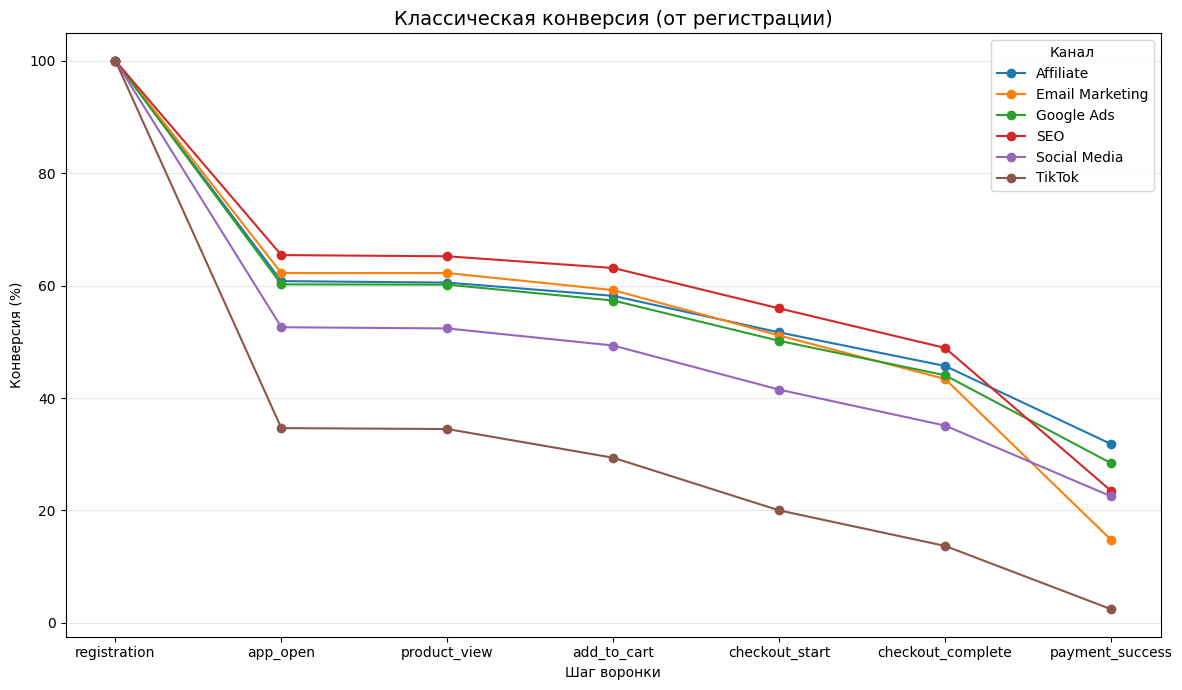

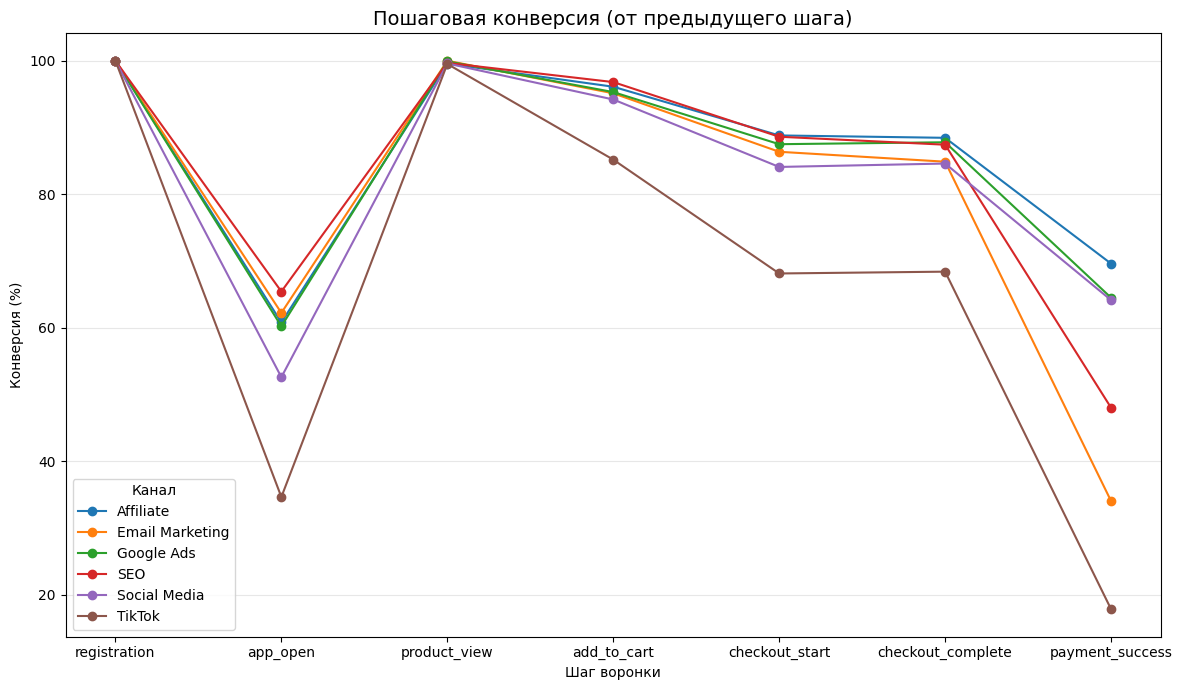

                    Affiliate  Email Marketing  Google Ads         SEO  \
registration       100.000000       100.000000  100.000000  100.000000   
app_open            60.800791        62.230920   60.221054   65.428744   
product_view        60.537156        62.230920   60.167400   65.217391   
add_to_cart         58.180919        59.197652   57.345209   63.134058   
checkout_start      51.672434        51.125245   50.177058   55.948068   
checkout_complete   45.707695        43.395303   44.049791   48.913043   
payment_success     31.817433        14.774951   28.415066   23.490338   

                   Social Media      TikTok  
registration         100.000000  100.000000  
app_open              52.596315   34.652590  
product_view          52.380952   34.486166  
add_to_cart           49.341948   29.379031  
checkout_start        41.493180   20.017683  
checkout_complete     35.104092   13.693572  
payment_success       22.517349    2.444352                       Affiliate  Email Ma

In [118]:
build_funnel(events_with_cohort,users,orders_with_cohort,segment_column='acq_channel')

При сегментации пользовательской воронки по каналам привлечения пользователей можно выделить канал с самыми низкими показателями конверсии - TikTok. Более 65% пользователей не начинают пользоваться продуктом после регистрации, более 80% из завершивших оформление заказа не осуществляют оплату. Финальная конверсия 2,4%. 
Потери на этапе оплаты в большей или меньшей степени выражены и для остальных каналов привлечения (от 30% для Affiliate до 65% для Email Marketing), при это основные потери, как и в целом для аудитории - на этапе начала использования и завершения оплаты. 

<div style="border:solid pink 5px; padding: 20px">
    <strong>ИНСАЙТ:</strong> Выявлена системная проблема с оплатой оформленных заказов, характерная для всех каналов привлечения. Критический уровень потерь наблюдается у каналов TikTok (80%), Email Marketing (65%) и SEO (50%). Каналы Affiliate, Google Ads и Social Media демонстрируют потери на уровне 30-35%. Это свидетельствует о низком качестве трафика, особенно с каналов TikTok, SEO и Email Marketing, чья аудитория значительно реже завершает оплату.
</div>

**Конверсия в заказ (CR) по каналам привлечения и когортам**

Рассчитаем конверсию в заказ для активных пользователей с сегментацией по каналу привлечения. 

In [119]:
#Все активные пользователи 
events_with_cohort.groupby(['acq_channel','cohort_month'])['user_id'].nunique()

acq_channel  cohort_month
Affiliate    2024-01-01       338
             2024-02-01       348
             2024-03-01       344
             2024-04-01       389
             2024-05-01       340
                             ... 
TikTok       2024-08-01       899
             2024-09-01      1070
             2024-10-01      1217
             2024-11-01      1098
             2024-12-01       670
Name: user_id, Length: 70, dtype: int64

In [120]:
#Все пользователи, разместившие заказы 
cr_channels=orders_with_cohort[orders_with_cohort['total_price'].notna()].groupby(['acq_channel','cohort_month'])['user_id'].nunique()/events_with_cohort.groupby(['acq_channel','cohort_month'])['user_id'].nunique()
cr_channels_pivot=cr_channels.reset_index().pivot(index='cohort_month',columns='acq_channel', values='user_id')

In [121]:
cr_channels_pivot.index=cr_channels_pivot.index.strftime('%Y-%m') 


In [122]:
cr_channels_pivot

acq_channel,Affiliate,Email Marketing,Google Ads,SEO,Social Media,TikTok
cohort_month,,,,,,
2024-01,0.497041,0.188034,0.489489,0.334842,0.445498,0.096552
2024-02,0.554598,0.234848,0.495146,0.353261,0.403509,0.065359
2024-03,0.552326,0.286957,0.462411,0.403846,0.443925,0.085366
2024-04,0.526992,0.341085,0.481586,0.378238,0.470899,0.082090
2024-05,0.602941,0.259615,0.425591,0.381910,0.414414,0.059140
2024-06,0.549645,0.204301,0.477444,0.391813,0.380952,0.083624
2024-07,0.485294,0.268966,0.495627,0.365854,0.461847,0.112500
2024-08,0.495468,0.185841,0.454044,0.353535,0.467290,0.071190
2024-09,0.501779,0.210526,0.438650,0.370787,0.402116,0.081308


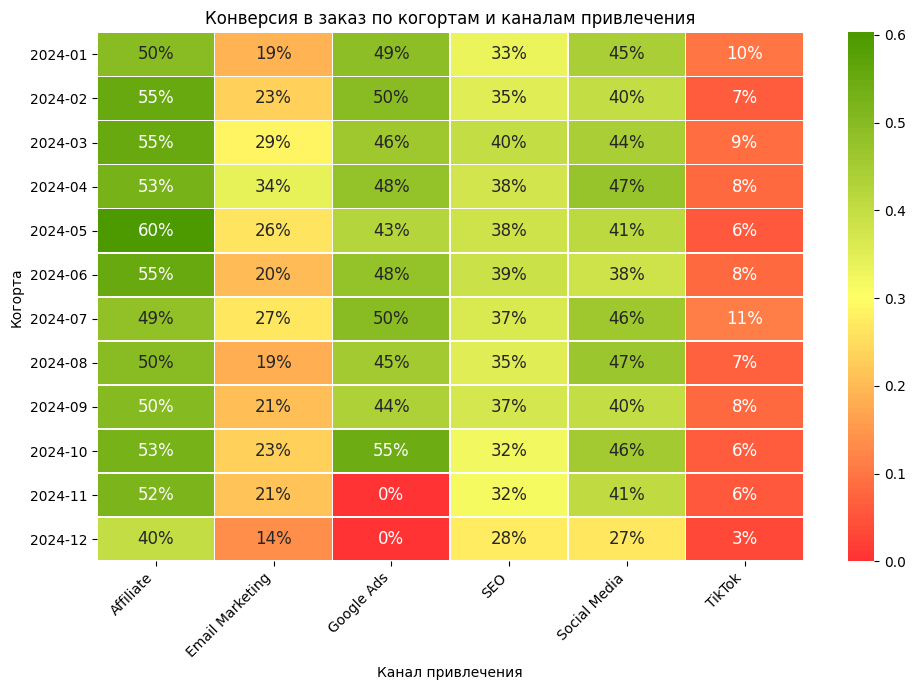

In [123]:
cr_channels_pivot=cr_channels_pivot.fillna(0)
plt.figure(figsize=(10,7))
sns.heatmap(cr_channels_pivot,
            cmap=cmap,
           annot=True,
           fmt='.0%',  
           linewidth=0.5,
           annot_kws={"size": 12})
plt.title('Конверсия в заказ по когортам и каналам привлечения')
plt.xlabel('Канал привлечения')
plt.ylabel('Когорта')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

По полученной тепловой карте можно отметить более эффективные по привлечению платящих пользователей каналы - это Affiliate(49-60%), Google Ads (43-55%), Social Media (38-47%). Стабильный, но чуть более низкий показатель конверсии демонстрирует канал привлечения SEO (32-39%). Конверсия в заказ среди пользователей, привлеченных через Email Marketing - 19-34%. Самый низкий показатель конверсии наблюдается для TikTok - 6-10%. Следует также отметить, что по всем каналам привлечения в декабре конверсия снизилась - следует проверить, не было ли глобального сбоя в работе приложения и/или нарушения логирования в декабре. В ноябре и декабре отсутствовали продажи через канал Google Ads - связано с прекращением деятельности организации в РФ.

**Средний чек (AOV)  по каналам привлечения**

In [124]:
aov_channel=(orders_with_cohort.groupby(['cohort_month','acq_channel'])['total_price'].sum()/orders_with_cohort.groupby(['cohort_month','acq_channel'])['order_id'].nunique()).unstack()

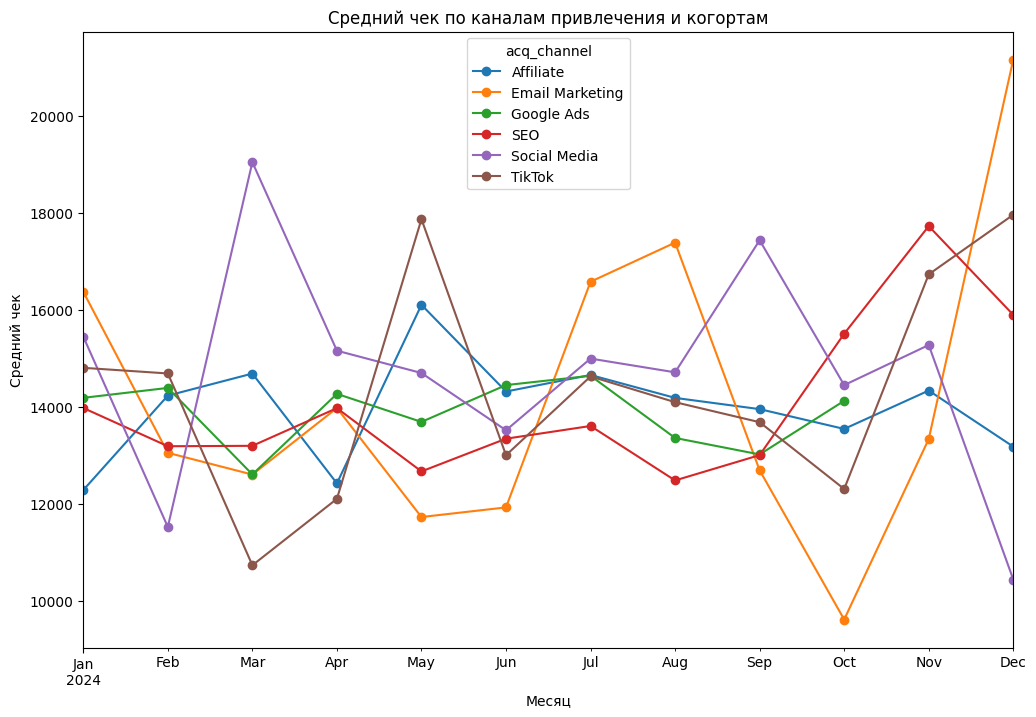

In [125]:
aov_channel.plot(   
    kind='line',
    xlabel='Месяц',
    ylabel='Средний чек',
    title='Средний чек по каналам привлечения и когортам',
    figsize=(12,8),
    marker='o'
)
plt.show()

Существенных различий по среднему чеку у пользователей, привлеченных через рекламные каналы нет. Для всех метрика имеет достаточно сильную волатильность, при этом среднее приблизительно одинаковое - около 14000.

**Выручка с пользователя (LTV) по каналам привлечения**

In [126]:
ltv_channel=orders_with_cohort.groupby(['acq_channel','cohort_month'])['total_price'].sum()*0.05/users.groupby(['acq_channel','cohort_month'])['user_id'].nunique()
ltv_channel.name = 'arpu'

In [127]:
ltv_channel_pivot_per_user=ltv_channel.reset_index().pivot(index='cohort_month',columns='acq_channel',values='arpu')
ltv_channel_pivot_per_user=ltv_channel_pivot_per_user.fillna(0)

In [128]:
ltv_channel_pivot_per_user.index = ltv_channel_pivot_per_user.index.strftime('%Y-%m') 


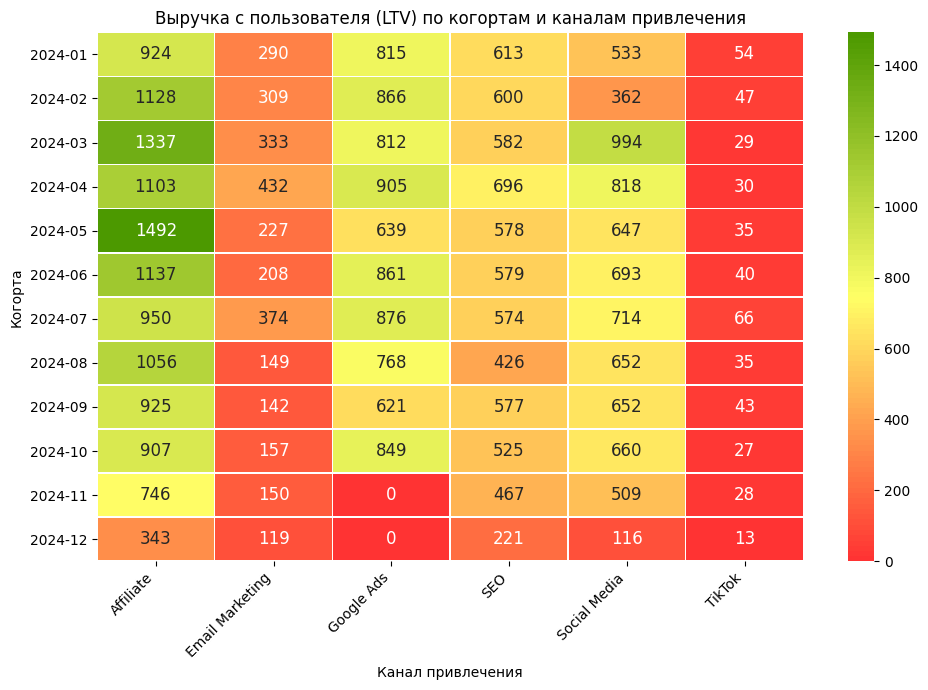

In [129]:
plt.figure(figsize=(10,7))
sns.heatmap(ltv_channel_pivot_per_user,
            cmap=cmap,
           annot=True,
           fmt='.0f',
           linewidth=0.5,
           annot_kws={"size": 12})
plt.title('Выручка с пользователя (LTV) по когортам и каналам привлечения')
plt.xlabel('Канал привлечения')
plt.ylabel('Когорта')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

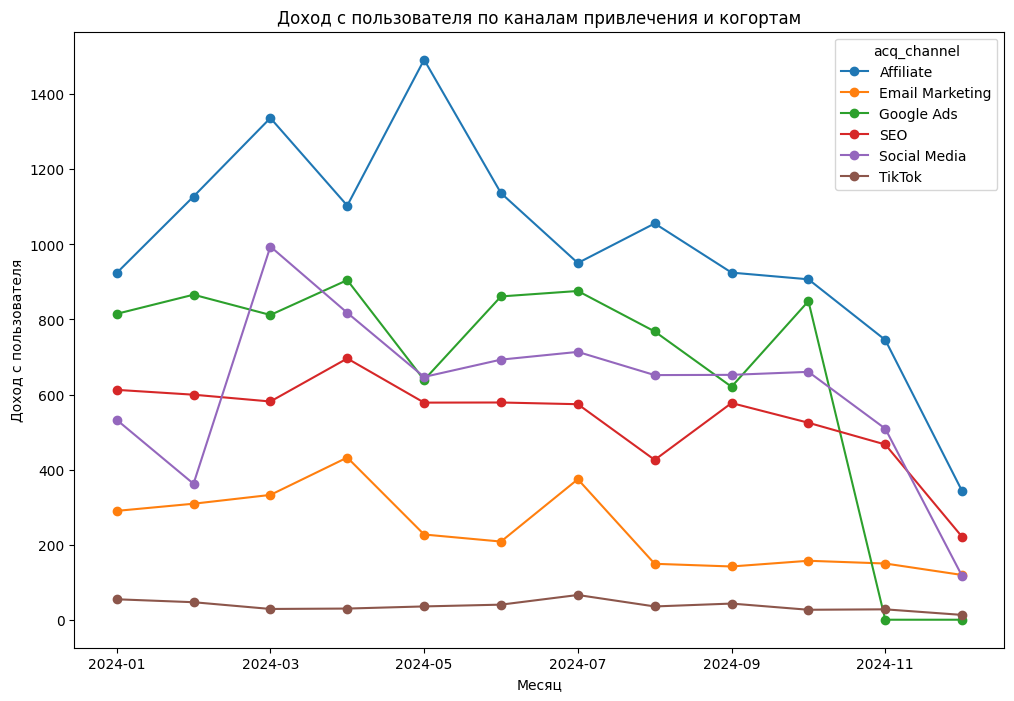

In [130]:
ltv_channel_pivot_per_user.plot(
    kind='line',
    xlabel='Месяц',
    ylabel='Доход с пользователя',
    title='Доход с пользователя по каналам привлечения и когортам',
    figsize=(12,8),
    marker='o'
)
plt.show()

Выручка с пользователей максимальна для каналов Affiliate и Google Ads, минимальна для TikTok. Для всех каналов прослеживается тенденция к снижению в октябре-декабре. 

**Затраты на привлечение пользователя (CAC)  по каналам привлечения**

In [131]:
#Преобразуем данные о маркетинговых тратах в сводную таблицу и рассчитаем на одного привлеченного пользователя
cac_channel_pivot=campaign_costs.pivot(index='spend_month',columns='acq_channel', values='budget')
cac_channel_pivot_per_user = cac_channel_pivot.div(users.groupby(['cohort_month','acq_channel'])['user_id'].nunique().unstack())


В датасете `users` отсутствуют пользователи, привлеченные через канал Direct (на который есть маркетинговые траты). Скорее всего, пользователи из Direct не регистрируются (конверсия = 0). Это может быть из-за:

- Некачественного трафика (боты, нецелевая аудитория)

- Технических проблем на странице регистрации для Direct-трафика

- Несоответствия обещаний в рекламе и реальности на сайте

- Проблема с логированием регистрации через Direct (в начале проекта были обнаружены 500+ пользователей с событиями в `events`, но без данных о регистрации в `users`). Возможно, регистрации через Direct не логировались и поэтому пользователи не попали в таблицу `users`

Необходимо разобраться с этим вопросом подробнее, а пока что исключим данный канал из тепловой карты

In [132]:
# Создаём копию данных без канала Direct
cac_clean = cac_channel_pivot_per_user.drop(columns=['Direct'])


In [133]:
cac_clean.index = cac_clean.index.strftime('%Y-%m') 


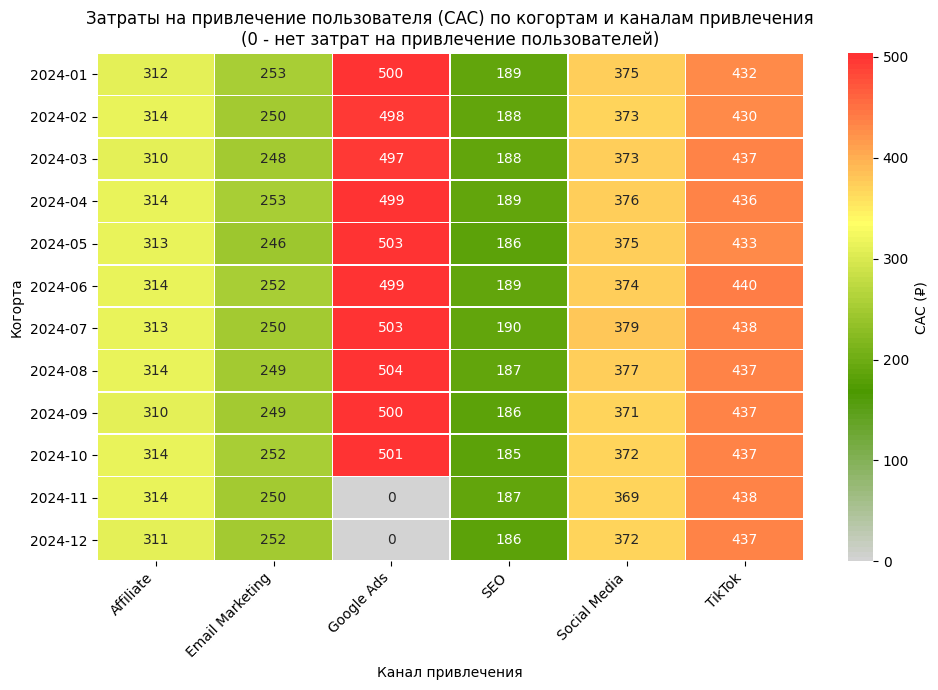

In [134]:
cmap_r = mcolors.LinearSegmentedColormap.from_list('green_red', ['lightgray', '#4C9900', '#FFFF66', '#FF3333'], N=100) 

# Для ячеек без пользователей ставим 0
cac_clean = cac_clean.fillna(0)


plt.figure(figsize=(10,7))
sns.heatmap(cac_clean,
            cmap=cmap_r,
            annot=True,
            fmt='.0f',
            linewidth=0.5,
            annot_kws={"size": 10},
            cbar_kws={'label': 'CAC (₽)'})
plt.title('Затраты на привлечение пользователя (CAC) по когортам и каналам привлечения\n(0 - нет затрат на привлечение пользователей)', 
          fontsize=12)
plt.xlabel('Канал привлечения')
plt.ylabel('Когорта')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Затраты на привлечение пользователей по всем каналам остаются стабильными в течение года, кроме Google Ads (который, вероятно, по той или иной причине перестал финансироваться в ноябре и декабре). Самые "дорогие" пользователи приходят через Google Ads и TikTok, самые "недорогие" - через SEO и Email Marketing.

**Окупаемость вложений (ROI) по каналам привлечения**

In [135]:
roi_pivot = (ltv_channel_pivot_per_user - cac_clean) / cac_clean

# Заменяем бесконечность и NaN на 0 (где CAC = 0)
roi_pivot = roi_pivot.replace([float('inf'), -float('inf')], 0).fillna(0)

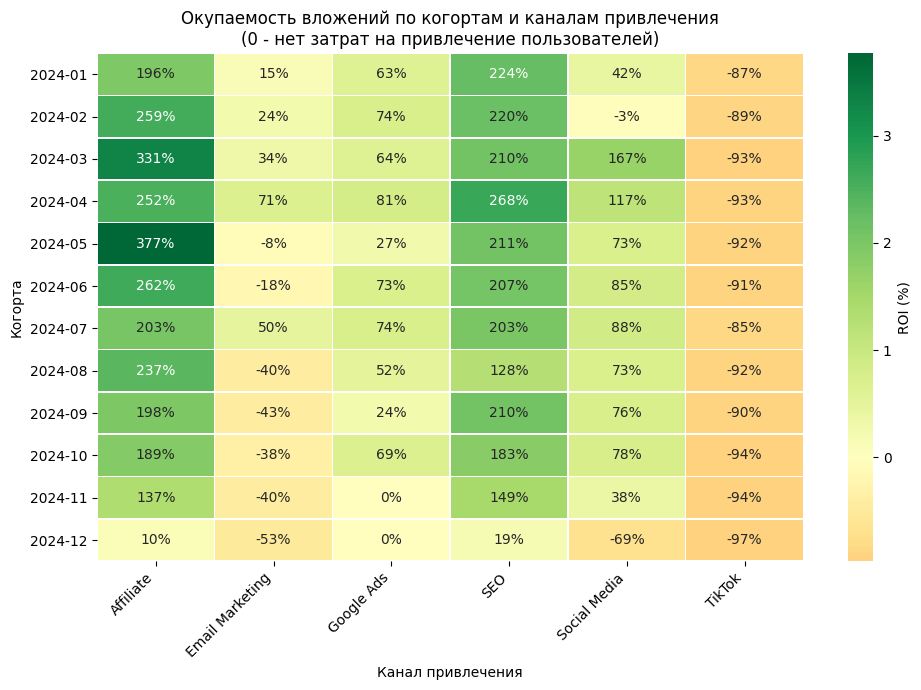

In [136]:
plt.figure(figsize=(10,7))
sns.heatmap(roi_pivot,
            cmap='RdYlGn',
            annot=True,
            fmt='.0%',  
            center=0,
            linewidth=0.5,
            annot_kws={"size": 10},
            cbar_kws={'label': 'ROI (%)'})
plt.title('Окупаемость вложений по когортам и каналам привлечения\n(0 - нет затрат на привлечение пользователей)', 
          fontsize=12)
plt.xlabel('Канал привлечения')
plt.ylabel('Когорта')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

По тепловой карте можно сделать выводы о том, что каналы привлечения Affiliate, SEO имеют высокие показатели окупаемости - от 137% до 377%, в то время как привлечение пользователей через TikTok оказывается убыточным в течение всего года, и через Email Marketing - во втором полугодии.

**Retention по каналам привлечения**

Для оценки удержания пользователей по различным каналам рассмотрим недельные когорты, горизонт анализа 12 недель (ранее было определено, что 90% пользователей не возвращаются в продукт спустя 3 месяца после регистрации).

In [137]:
activity_data['n_week'] = ((activity_data['event_week'] - activity_data['cohort_week']).dt.days // 7)
#Отфильтруем события за первые 12 недель жизненного цикла пользователей, а также события регистрации - где отсутствует event_week
activity_data_12_weeks=activity_data[(activity_data['n_week']<=12)|(activity_data['n_week'].isna())]


In [138]:
activity_data_12_weeks['n_week'].unique()

array([nan,  0.,  7.,  2.,  3.,  4.,  1.,  5.,  9., 10.,  6., 12.,  8.,
       11.])

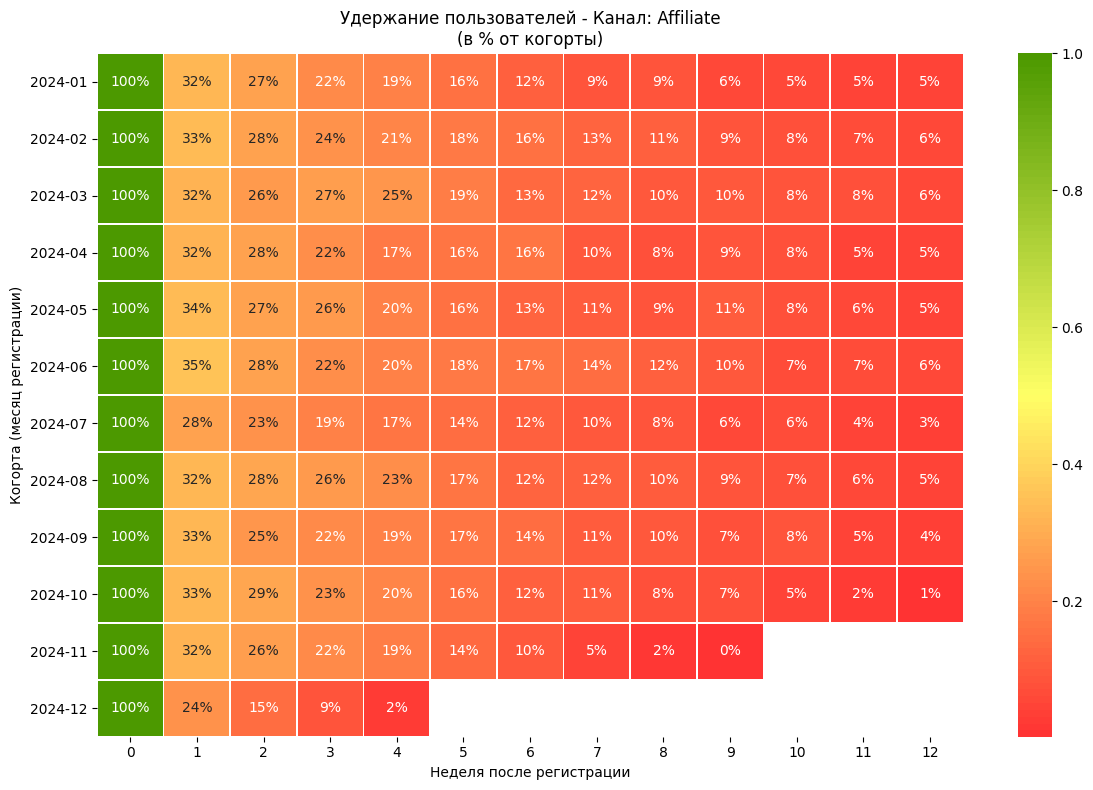

  Нет данных для канала Direct


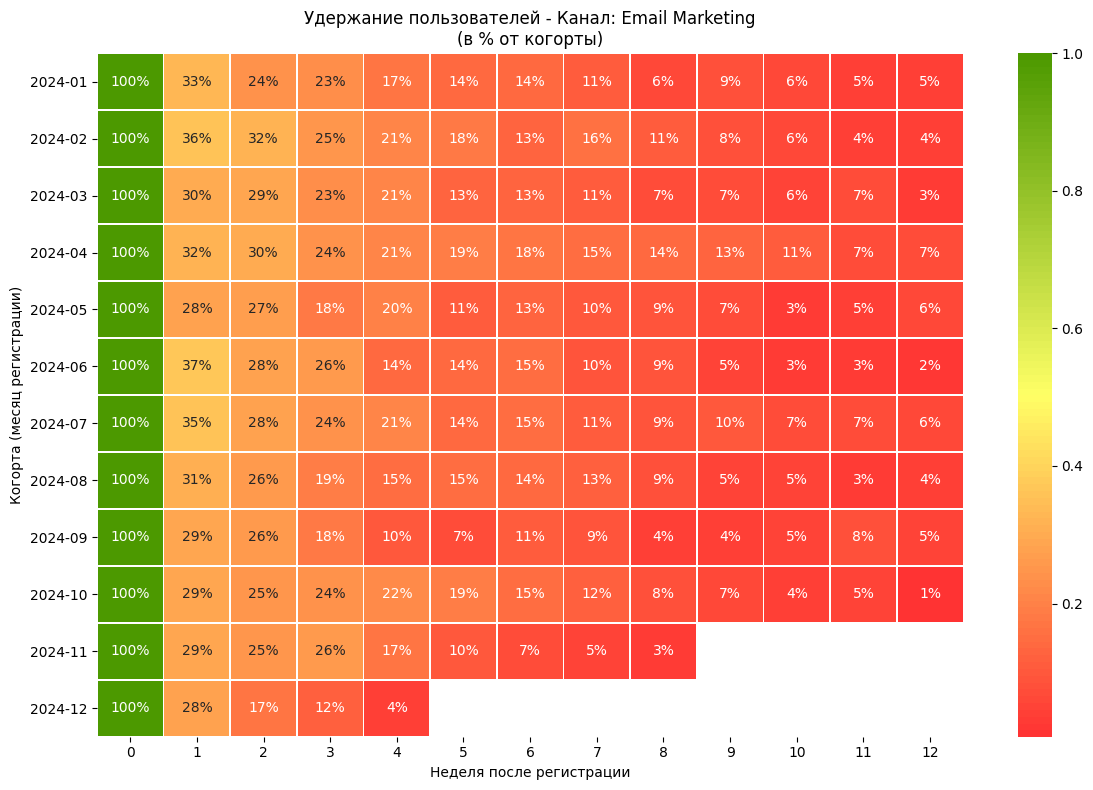

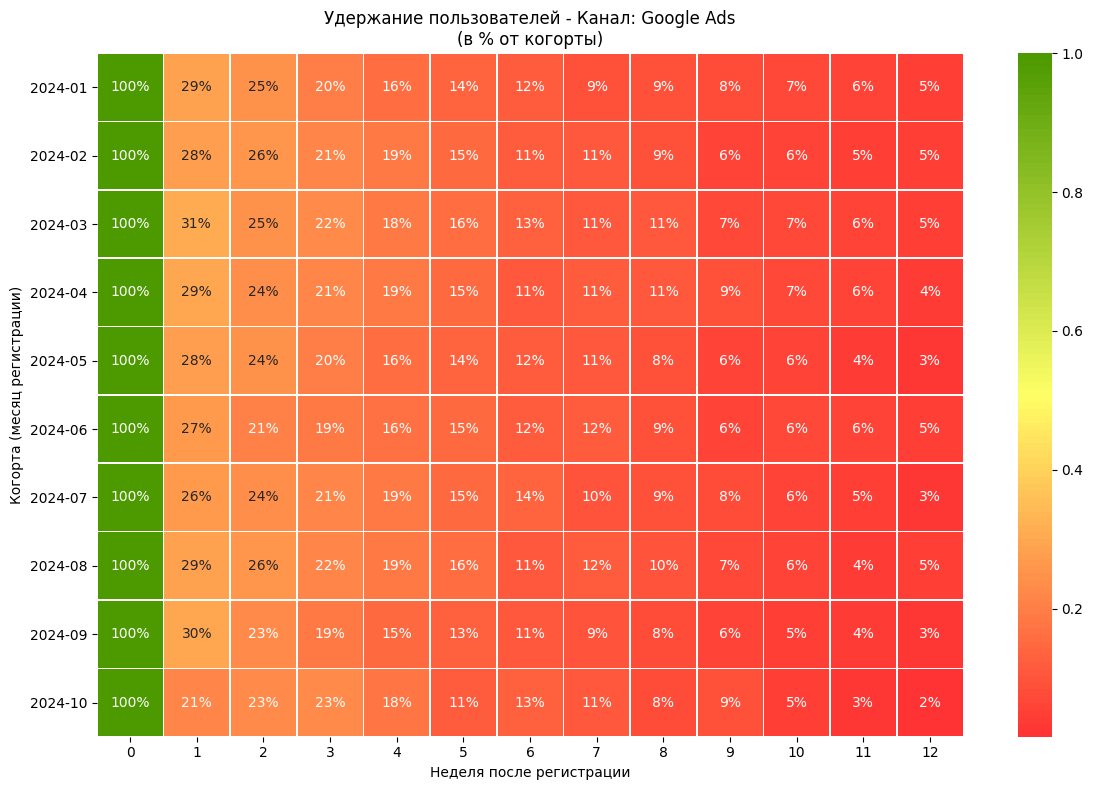

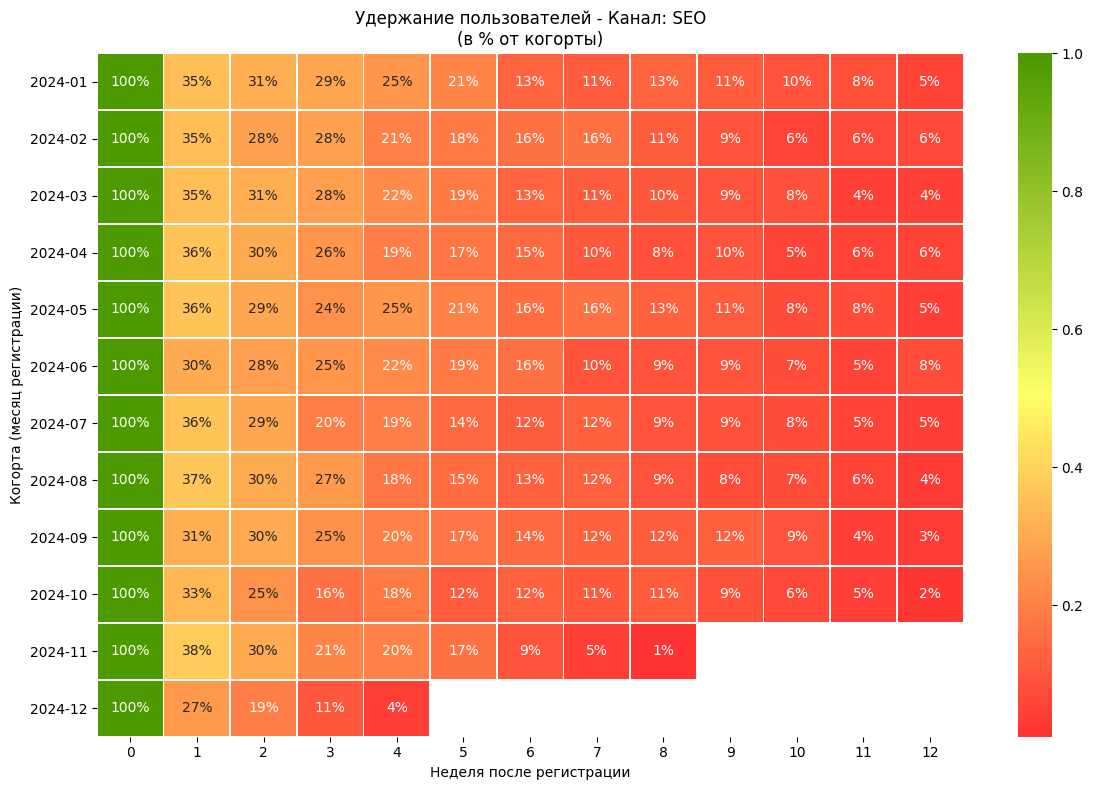

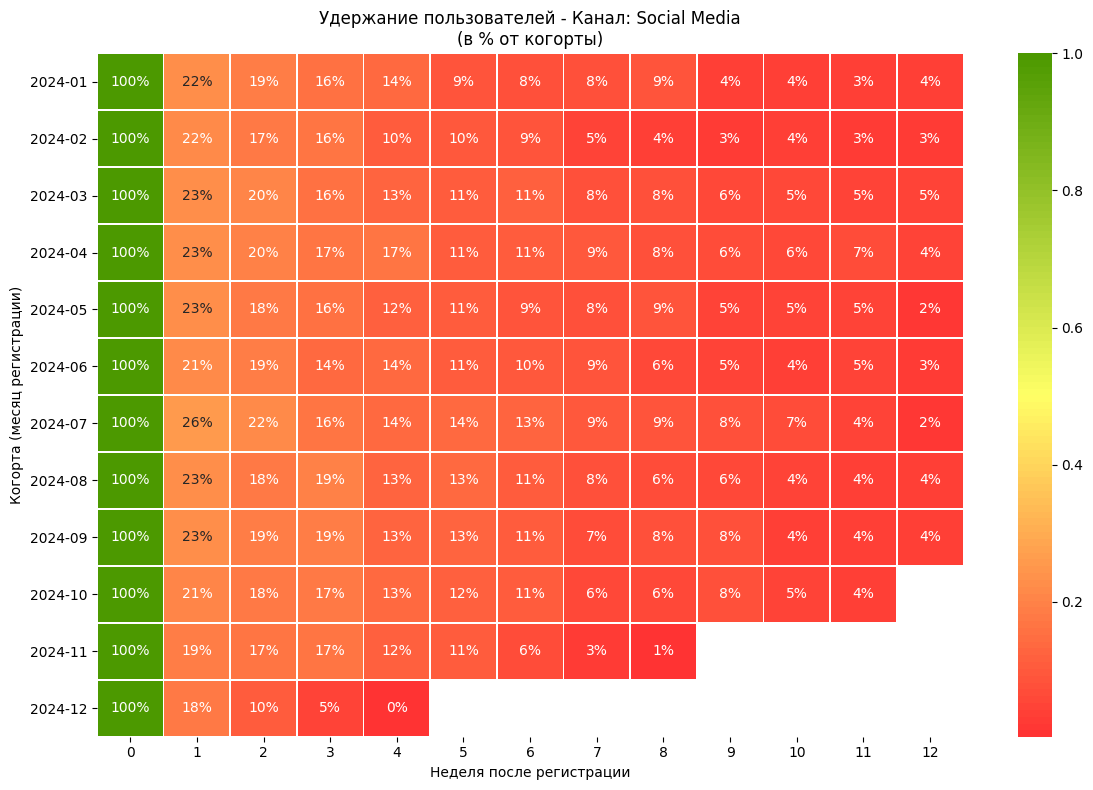

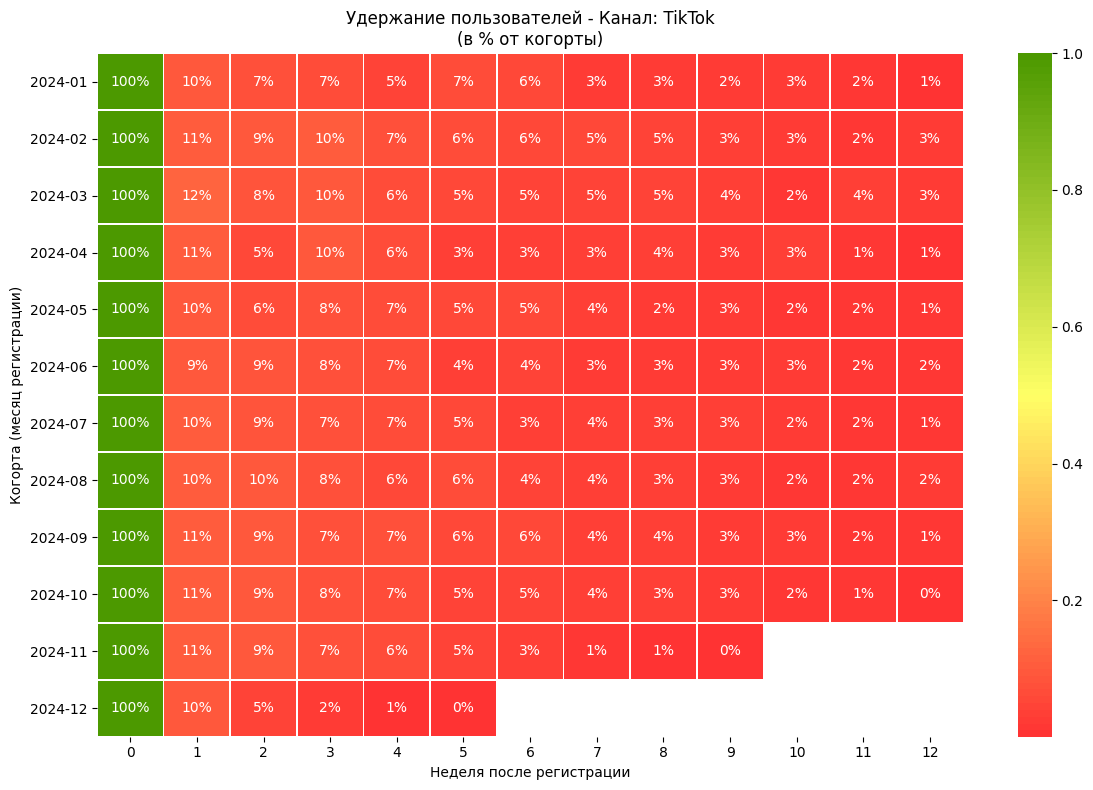

In [139]:
# Присоединяем каналы к активности
activity_with_channel = activity_data_12_weeks.merge(
    cohort_data[['user_id', 'acq_channel']],
    on='user_id',
    how='left'
)

# Объединяем данные когорт и активности
all_activity_channel = pd.concat([
    cohort_data[['user_id', 'acq_channel', 'cohort_month', 'n_week']],
    activity_with_channel[['user_id', 'acq_channel', 'cohort_month', 'n_week']]
], ignore_index=True)

# Приводим n_week к целому типу
all_activity_channel['n_week'] = all_activity_channel['n_week'].fillna(0).astype(int)


def calculate_retention(data, channel_name):
    """Расчет retention для конкретного канала"""
    
    # Фильтруем данные по каналу
    channel_data = data[data['acq_channel'] == channel_name].copy()
    
    if channel_data.empty:
        print(f"  Нет данных для канала {channel_name}")
        return None
    
    # Считаем количество уникальных пользователей по когортам и неделям
    cohort_pivot = channel_data.groupby(['cohort_month', 'n_week'])['user_id'].nunique().unstack()
    
    # Размер когорты (неделя 0)
    cohort_size = cohort_pivot[0]
    
    retention_channel = cohort_pivot.div(cohort_size, axis=0) 
    
    retention_channel.index = retention_channel.index.strftime('%Y-%m')
    
    return retention_channel


# Строим тепловые карты для каждого канала
for i, channel in  enumerate(sorted(campaign_costs['acq_channel'].unique())):
    
    # Рассчитываем retention
    retention_channel = calculate_retention(all_activity_channel, channel)
    
    if retention_channel is None:
        continue

    fig, ax = plt.subplots(figsize=(12, 8))
    
    heatmap = sns.heatmap(
        retention_channel,
        annot=True,          
        fmt='.0%',        
        cmap=cmap,     
        linewidths=0.5,
        linecolor='white'
    )
    
    # Настройка графика
    ax.set_title(
        f'Удержание пользователей - Канал: {channel}\n(в % от когорты)'
    )
    ax.set_xlabel('Неделя после регистрации')
    ax.set_ylabel('Когорта (месяц регистрации)')
    
    # Форматирование подписей
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    # Добавляем информацию о размере когорт
    cohort_sizes = all_activity_channel[all_activity_channel['acq_channel'] == channel]
    cohort_sizes = cohort_sizes[cohort_sizes['n_week'] == 0].groupby('cohort_month')['user_id'].nunique()
    # print(channel,cohort_pivot,cohort_sizes)
    
    plt.tight_layout()
    plt.show()
    
    plt.close(fig)


По всем каналам возвращаемость зарегистрированных пользователей низкая, но особенно - у привлеченных через TikTok. Наиболее высокие показатели возвращаемости (но тоже низкие, не выше 40% уже через неделю после установки) - через AfFiliate, SEO, Email Marketing. Колоссальных изменений в удержании пользователей по каналам не наблюдается, значит падение общего Retention связано с перераспределением пользователей по каналам. 

#### Сегментация по сегменту пользователя

**Количество привлеченных пользователей по сегменту пользователя**

In [140]:
#Расчитаем долю пользователей в каждом сегменте и когорте
users_by_segment=users.groupby(['cohort_month','buyer_segment'])['user_id'].nunique().unstack()
users_by_segment_share=users_by_segment.div(cohort_size, axis=0)*100

<AxesSubplot:title={'center':'Процент привлеченных пользователей по сегменту'}, xlabel='Когорта', ylabel='Процент пользователей в сегменте'>

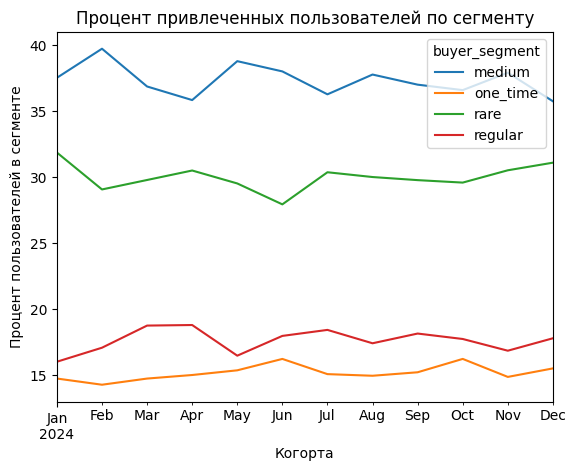

In [141]:
users_by_segment_share.plot(
    kind='line',
    xlabel='Когорта',
    ylabel='Процент пользователей в сегменте',
    title='Процент привлеченных пользователей по сегменту'
)

Распределение пользователей по сегментам достаточно однородно, без трендов к изменению соотношения долей. 

**Конверсия в заказ для активных пользователей  по сегменту пользователя**

In [142]:
cr_buyer_segment=(orders_with_cohort[orders_with_cohort['total_price'].notna()].groupby(['cohort_month','buyer_segment'])['user_id'].nunique()/events_with_cohort.groupby(['cohort_month','buyer_segment'])['user_id'].nunique()).unstack()
cr_buyer_segment.index = cr_buyer_segment.index.strftime('%Y-%m') 


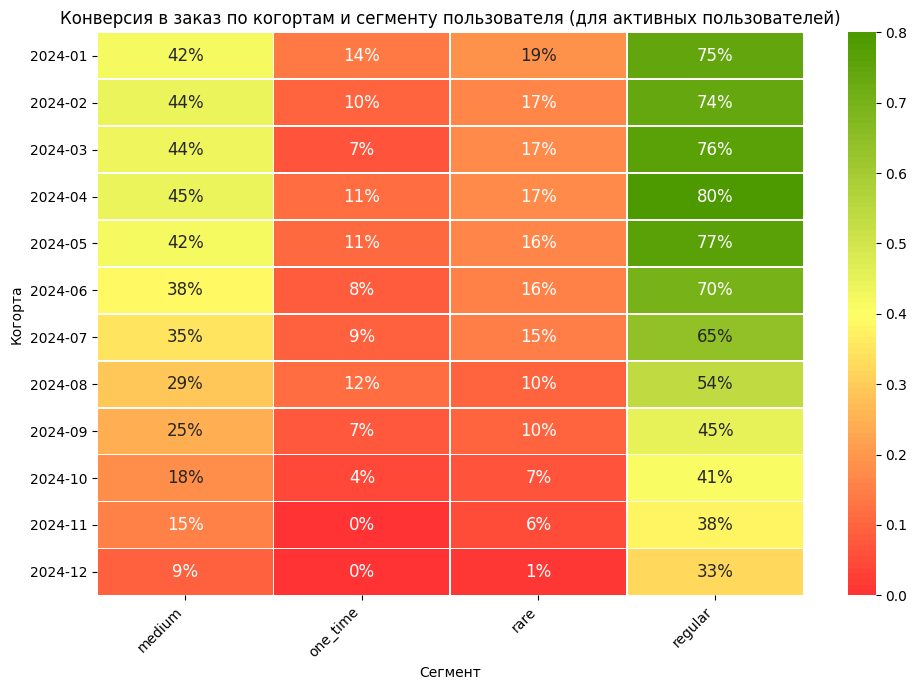

In [143]:
cr_buyer_segment=cr_buyer_segment.fillna(0)
plt.figure(figsize=(10,7))
sns.heatmap(cr_buyer_segment,
            cmap=cmap,
           annot=True,
           fmt='.0%',  
           linewidth=0.5,
           annot_kws={"size": 12})
plt.title('Конверсия в заказ по когортам и сегменту пользователя (для активных пользователей)')
plt.xlabel('Сегмент')
plt.ylabel('Когорта')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

По тепловой карте можем сделать вывод о том, что конверсия у всех сегментов покупателей во втором полугодии снизилась по сравнению с первым. Для "регулярных" в первом полугодии была высокая конверсия в заказ - 70-80%, а к концу года упала до 33%. У "средних" метрика составляла 38-45%, а к концу года упала до 9%. У "разовых" и "редких" клиентов конверсия была низкой и снизилась до ничтожно малых значений. 

**Средняя выручка с активного пользователя (ARPU) по сегменту пользователя**

In [144]:
arpu_by_segment=orders_with_cohort.groupby(['cohort_month','buyer_segment'])['total_price'].sum().unstack().div((events_with_cohort.groupby(['cohort_month','buyer_segment'])['user_id'].nunique()).unstack())*0.05

In [145]:
arpu_by_segment.index = arpu_by_segment.index.strftime('%Y-%m') 


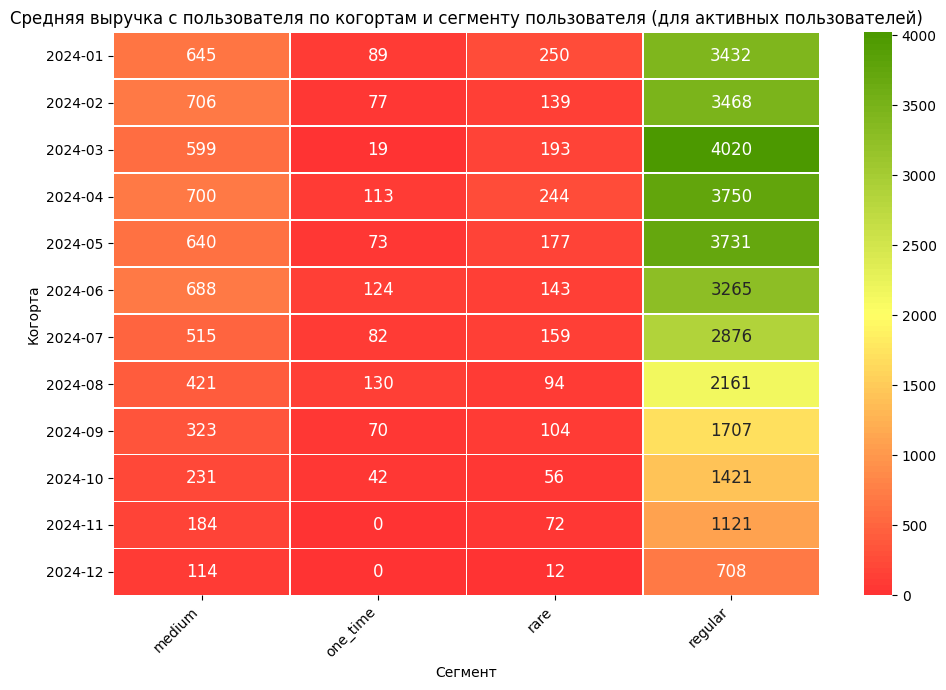

In [146]:
arpu_by_segment=arpu_by_segment.fillna(0)
plt.figure(figsize=(10,7))
sns.heatmap(arpu_by_segment,
            cmap=cmap,
           annot=True,
           fmt='.0f',  
           linewidth=0.5,
           annot_kws={"size": 12})
plt.title('Средняя выручка с пользователя по когортам и сегменту пользователя (для активных пользователей)')
plt.xlabel('Сегмент')
plt.ylabel('Когорта')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Ожидаемо, для регулярных покупателей выручка существенно выше, чем для остальных. Также на тепловой карте повторяется тренд на снижение выручки во втором полугодии (для всех сегментов).

**Средний чек (AOV) по сегменту пользователя**

In [147]:
aov_by_segment=orders_with_cohort.groupby(['cohort_month','buyer_segment'])['total_price'].sum().unstack()/orders_with_cohort.groupby(['cohort_month','buyer_segment'])['order_id'].nunique().unstack()

In [148]:
aov_by_segment.index = aov_by_segment.index.strftime('%Y-%m') 


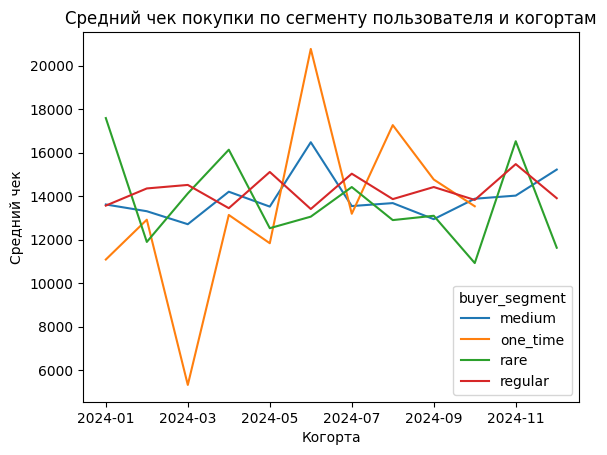

In [149]:
aov_by_segment.plot(
    kind='line',
    xlabel='Когорта',
    ylabel='Средний чек',
    title='Средний чек покупки по сегменту пользователя и когортам'
)
plt.show()

Средний чек для всех сегментов приблизительно одинаков, для пользователей, разместивших только 1 заказ, волатильность выше.

В данных отсутствуют записи от пользователей сегмента `one_time` в ноябре и декабре. Выше в проекте было установлено, что за этот же период отсутствовали данные по каналу привлечения `Google Ads`. Следует проверить корректность логирования за этот период - возможно, часть данных отсутствует.

Сегментация по сегментам пользователя не дала интересных инсайтов - для всех сегментов динамика метрик одинакова. 

#### Сегментация по категории товара

**Средний чек по категории товара**

Выделим 5 категорий товаров, вносящих наибольший вес в выручку с заказов, а остальные объединим в группу "Другие"

In [150]:
# Рассчитываем выручку по категориям
category_revenue = orders_with_cohort.groupby('category_name')['total_price'].sum().sort_values(ascending=False)

# Выделяем топ-5 категорий
top5_categories = category_revenue.head(5).index.tolist()
print(f"Топ-5 категорий: {top5_categories}")
print(f"Их доля в выручке: {(category_revenue.head(5).sum() / category_revenue.sum() * 100).round(1)}%")

Топ-5 категорий: ['Мебель для дома', 'Бытовая техника', 'Украшения и часы', 'Товары для туризма', 'Спортивный инвентарь']
Их доля в выручке: 45.1%


In [151]:
# Создаем новую колонку с группировкой
orders_with_cohort['category_rev'] = orders_with_cohort['category_name'].apply(
    lambda x: x if x in top5_categories else 'Другие'
)

In [152]:
orders_with_cohort

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month,order_id,order_month,total_price,category_name,n_month,category_rev
0,2,2024-01-01 19:01:00,53,M,Москва,Email Marketing,rare,2024-01-01,2024-01-01,NaN,NaT,NaN,NaN,0,Другие
1,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01,1.0,2024-01-01,11078.26,Инструменты и садовый инвентарь,0,Другие
2,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01,2.0,2024-01-01,11340.38,Инструменты и садовый инвентарь,0,Другие
3,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01,3.0,2024-01-01,21784.18,Инструменты и садовый инвентарь,0,Другие
4,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01,4.0,2024-01-01,11078.26,Инструменты и садовый инвентарь,0,Другие
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41859,44749,2024-12-30 17:15:00,55,F,Москва,Affiliate,regular,2024-12-30,2024-12-01,NaN,NaT,NaN,NaN,0,Другие
41860,44751,2024-12-30 21:24:00,66,F,Другие регионы,TikTok,medium,2024-12-30,2024-12-01,NaN,NaT,NaN,NaN,0,Другие
41861,44783,2024-12-30 09:25:00,68,M,Другие регионы,TikTok,one_time,2024-12-30,2024-12-01,NaN,NaT,NaN,NaN,0,Другие
41862,44808,2024-12-31 12:52:00,19,F,Москва,Email Marketing,medium,2024-12-30,2024-12-01,NaN,NaT,NaN,NaN,0,Другие


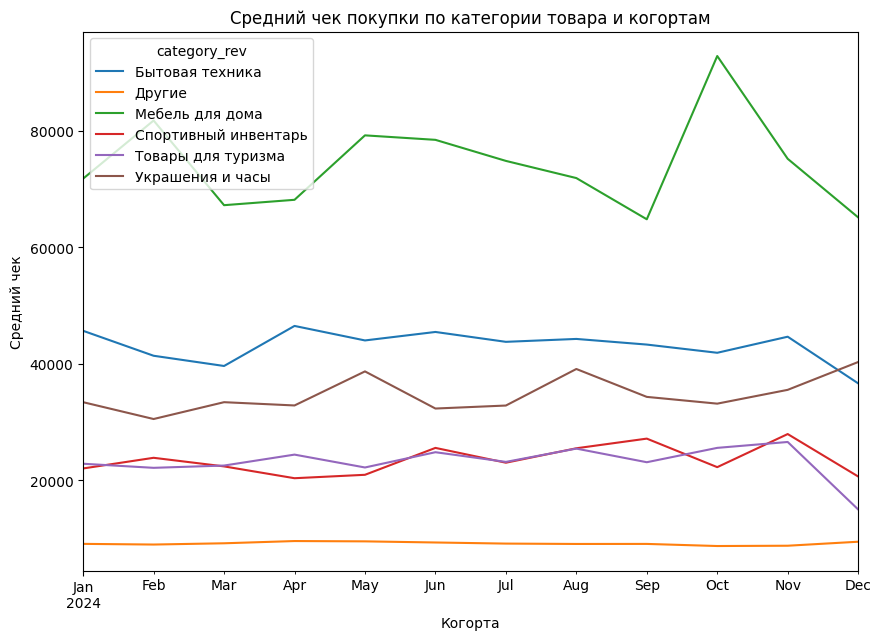

In [153]:
aov_by_category=orders_with_cohort[orders_with_cohort['total_price'].notna()].groupby(['cohort_month','category_rev'])['total_price'].mean().unstack()


aov_by_category.plot(    
    kind='line',
    xlabel='Когорта',
    ylabel='Средний чек',
    title='Средний чек покупки по категории товара и когортам',
    figsize=(10,7)
)
plt.show()

Средний чек покупки по категориям в течение 2024 года - без заметных трендов.

Рассмотрим срез по выручке по каналам привлечения и категориям товаров.

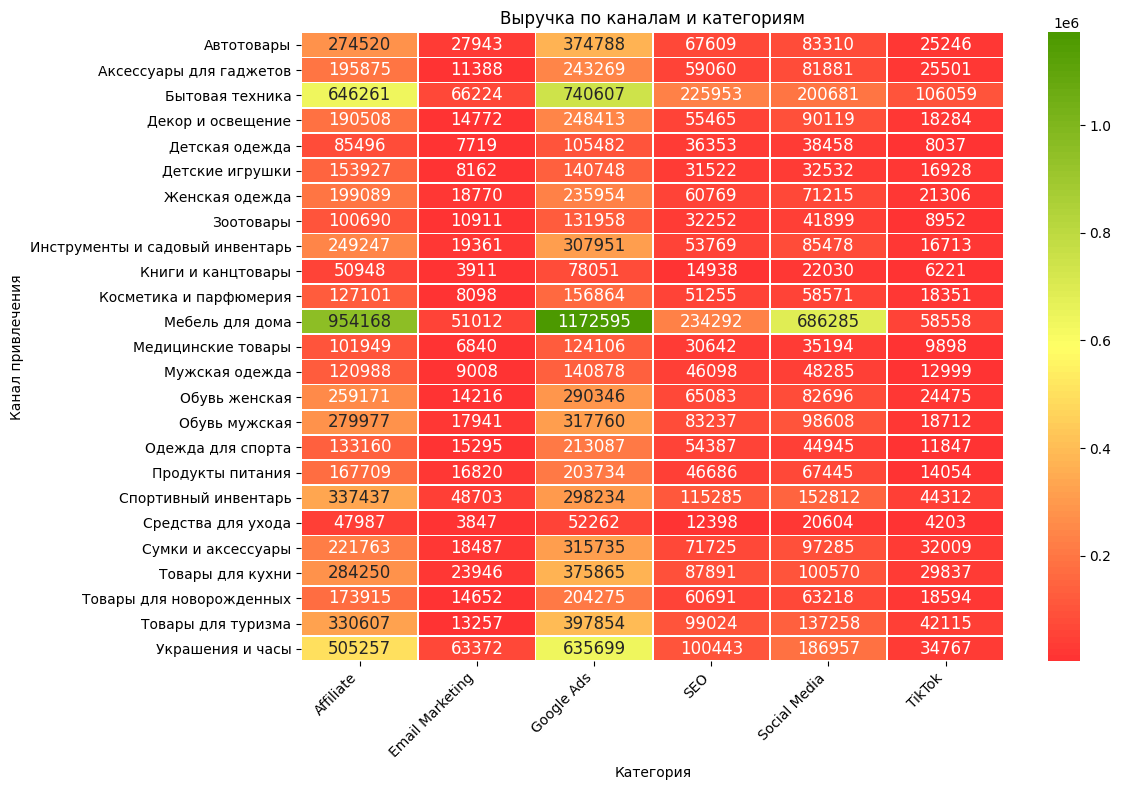

In [154]:
channel_category_revenue = (orders_with_cohort.pivot_table(
    index='category_name', 
    columns='acq_channel', 
    values='total_price', 
    aggfunc='sum',
    fill_value=0
))*0.05


plt.figure(figsize=(12, 8))
sns.heatmap(channel_category_revenue, 
            annot=True, 
            annot_kws={"size": 12},
            fmt='.0f', 
            linewidth=0.5,
            cmap=cmap)

plt.title('Выручка по каналам и категориям')
plt.xlabel('Категория')
plt.ylabel('Канал привлечения')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



Самые прибыльные комбинации категорий и каналов - это 
- бытовая техника+ Affiliate/Google_Ads
- мебель для дома + Affiliate/Google_Ads/Social Media
- украшения и часы + Affiliate/Google_Ads
- спортивный инвентарь + Affiliate/Google_Ads
- товары для туризма + Affiliate/Google_Ads


#### Сегментация по региону пользователя

**Продуктовая воронка по региону пользователя**

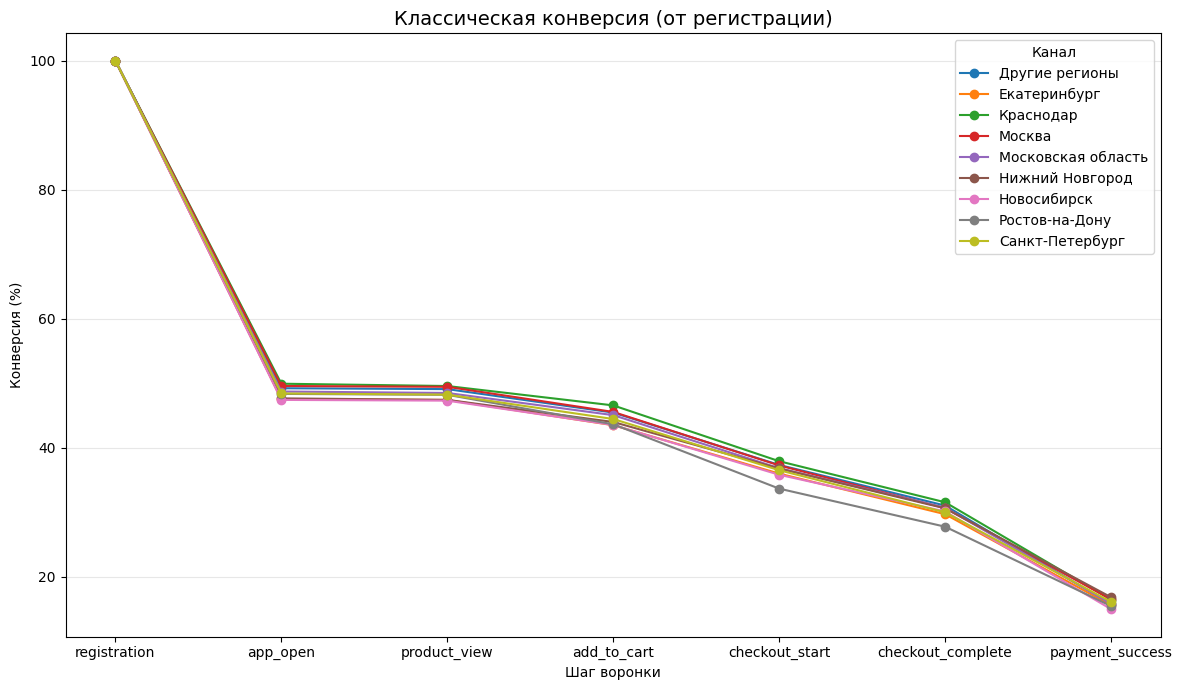

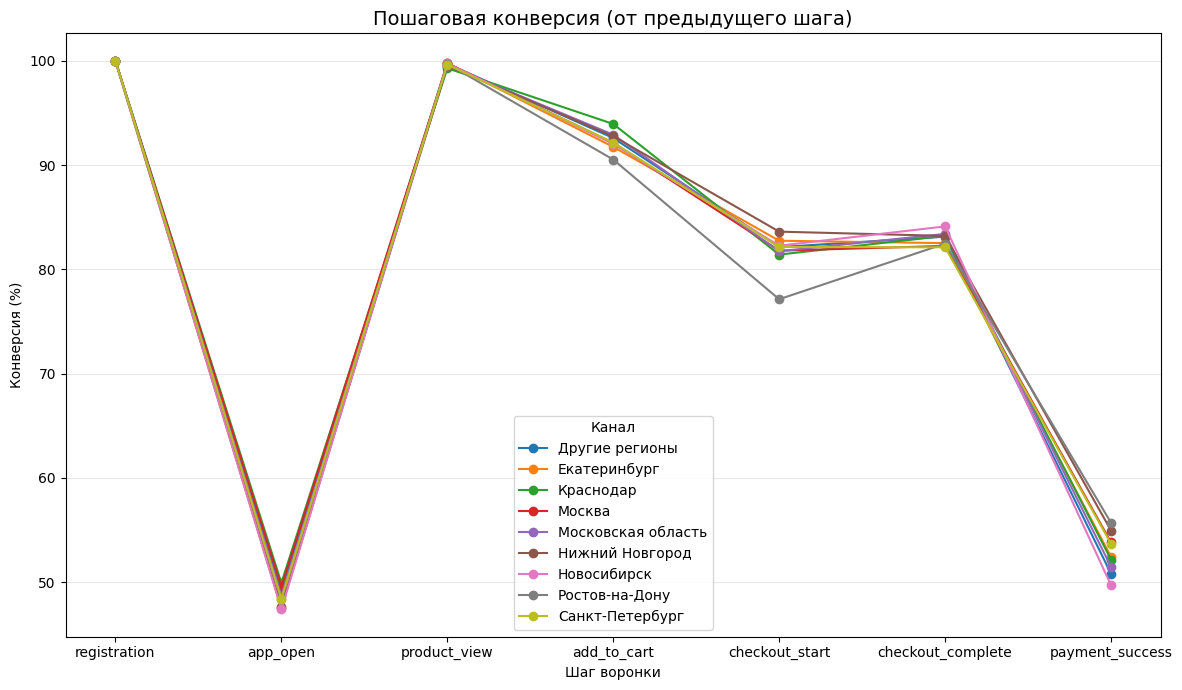

                   Другие регионы  Екатеринбург   Краснодар      Москва  \
registration           100.000000    100.000000  100.000000  100.000000   
app_open                49.228438     47.505828   49.928469   49.575691   
product_view            49.090659     47.412587   49.570815   49.447942   
add_to_cart             45.453293     43.496503   46.566524   45.551601   
checkout_start          37.331221     35.990676   37.911302   37.257049   
checkout_complete       31.034720     29.696970   31.545064   30.641482   
payment_success         15.768807     15.571096   16.452074   16.488731   

                   Московская область  Нижний Новгород  Новосибирск  \
registration               100.000000       100.000000   100.000000   
app_open                    48.717949        47.654462    47.417295   
product_view                48.492533        47.425629    47.301219   
add_to_cart                 45.054945        43.993135    43.528729   
checkout_start              36.827275       

In [155]:
build_funnel(events_with_cohort,users,orders_with_cohort,segment_column='region')

Существенных региональных различий в продуктовой воронке не выявлено. Для Ростова-на-Дону наблюдается более заметное снижение на этапе начала оформления заказа (33.7%) по сравнению с другими регионами (35.8-37.9%). При этом итоговая конверсия в успешную оплату в Ростове-на-Дону (15.5%) находится на уровне остальных регионов (14.9-16.8%). Это может указывать на поведенческую особенность аудитории данного региона.

**Конверсия в заказ по региону**

In [156]:
cr_region=(orders_with_cohort[orders_with_cohort['total_price'].notna()].groupby(['cohort_month','region'])['user_id'].nunique()/events_with_cohort.groupby(['cohort_month','region'])['user_id'].nunique()).unstack()
cr_region.index = cr_region.index.strftime('%Y-%m') 


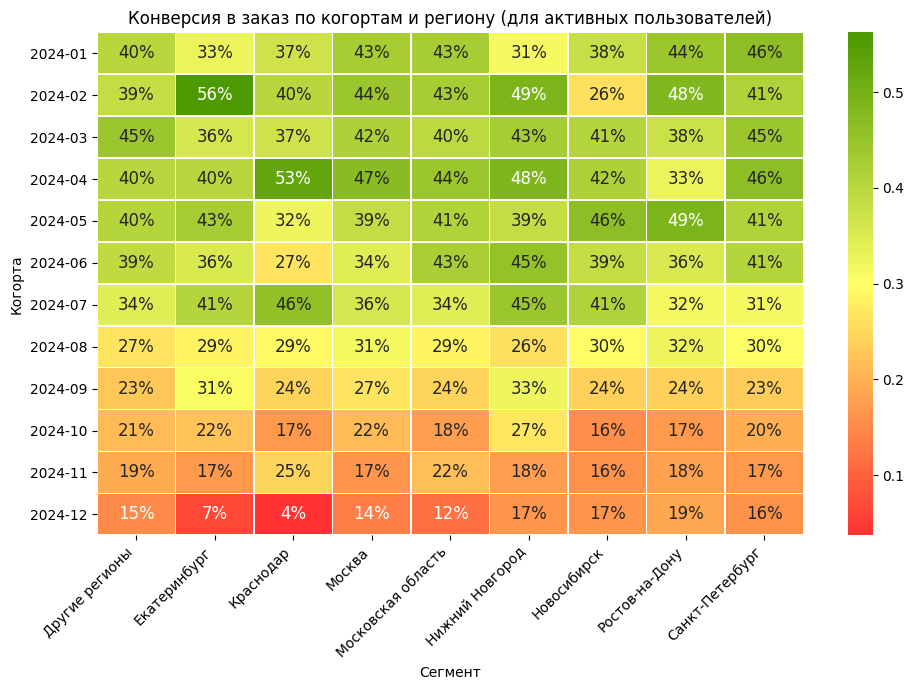

In [157]:
cr_region=cr_region.fillna(0)
plt.figure(figsize=(10,7))
sns.heatmap(cr_region,
            cmap=cmap,
           annot=True,
           fmt='.0%',  
           linewidth=0.5,
           annot_kws={"size": 12})
plt.title('Конверсия в заказ по когортам и региону (для активных пользователей)')
plt.xlabel('Сегмент')
plt.ylabel('Когорта')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Для всех регионов конверсия в заказ падает во втором полугодии, по сравнению с первым. Существенных различий по регионам нет.

#### Сегментация по типу устройства

**Продуктовая воронка по типу устройства**

В таблицах `orders, users` отсутствует информация о типе устройства. Проверим, является тип устройства уникальным для пользователя.

In [158]:
user_devices_count=events.groupby('user_id')['device'].nunique()

In [159]:
user_devices_count[user_devices_count!=1]

Series([], Name: device, dtype: int64)

Для каждого пользователя встречается только один тип устройства. Поскольку тип устройства известен только в таблице `events` - для пользователей, которые после регистрации пользовались приложением, то в настоящем блоке рассчитана продуктовая воронка по активным пользователям (и итоговая конверсия - относительно количества активных пользователей).

In [160]:
user_devices=events[['user_id','device']].drop_duplicates()

In [161]:
orders_with_cohort=pd.merge(orders_with_cohort,user_devices, on='user_id',how='left')

In [162]:
users=pd.merge(users,user_devices, on='user_id',how='left')

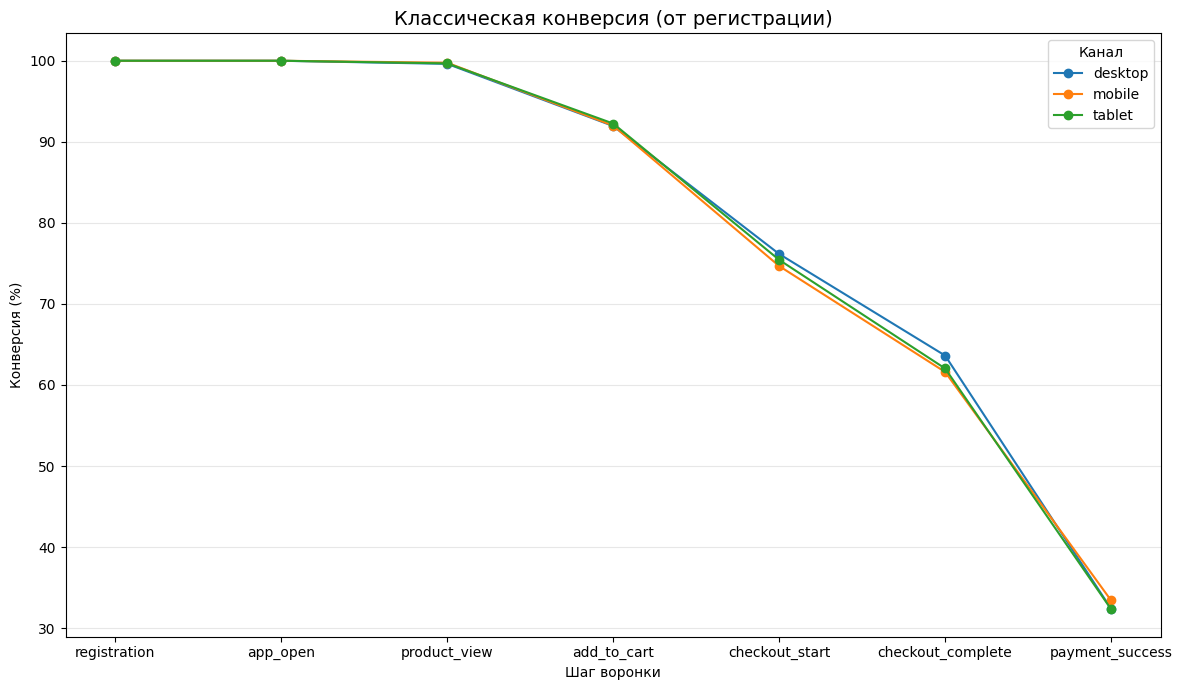

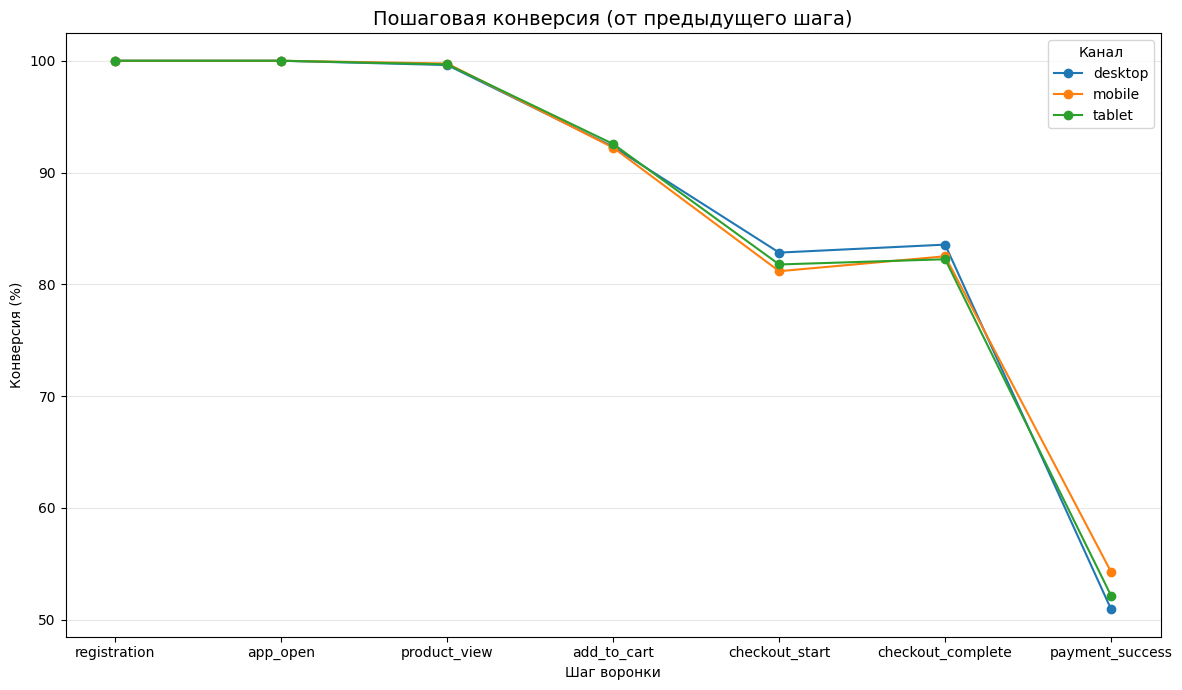

                      desktop      mobile      tablet
registration       100.000000  100.000000  100.000000
app_open           100.000000  100.000000  100.000000
product_view        99.615701   99.751141   99.675279
add_to_cart         91.943453   91.995023   92.249047
checkout_start      76.159758   74.671644   75.434138
checkout_complete   63.628877   61.606526   62.035861
payment_success     32.404612   33.430112   32.345052                       desktop      mobile      tablet
registration       100.000000  100.000000  100.000000
app_open           100.000000  100.000000  100.000000
product_view        99.615701   99.751141   99.675279
add_to_cart         92.298154   92.224532   92.549575
checkout_start      82.833259   81.169222   81.772268
checkout_complete   83.546585   82.503240   82.238443
payment_success     50.927524   54.263914   52.139281


In [163]:
build_funnel(events_with_cohort,users[users['device'].notna()],orders_with_cohort,segment_column='device')

Существенных различий в продуктовой воронке по типу устройства нет.

**Конверсия в заказ по типу устройства**

In [164]:
cr_device=(orders_with_cohort[orders_with_cohort['total_price'].notna()].groupby(['cohort_month','device'])['user_id'].nunique()/events_with_cohort.groupby(['cohort_month','device'])['user_id'].nunique()).unstack()
cr_device.index = cr_device.index.strftime('%Y-%m') 


<AxesSubplot:title={'center':'Конверсия в заказ по типам устройства'}, xlabel='Когорта', ylabel='Конверсия в заказ'>

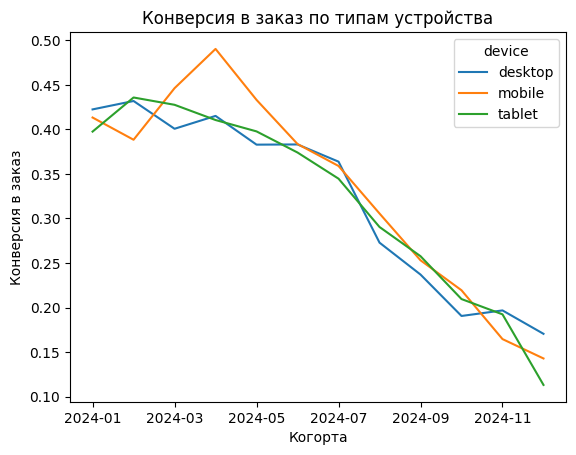

In [165]:
cr_device.plot(
    kind='line',
    xlabel='Когорта',
    ylabel='Конверсия в заказ',
    title='Конверсия в заказ по типам устройства'
)

Динамика изменения конверсии в заказ по типу устройства примерно одинакова для всех типов. 

## Выводы по этапу 4

Представьте ключевые выводы в текстовом виде здесь или приложите ссылку на документ с презентацией.

Не забудьте предоставить доступ на просмотр и комментирование документа.

### Ключевые выводы
#### 1. Проблема с окупаемостью связана с перекосом в маркетинговые траты
**Наблюдение**: С июля 2024 года маркетинговый бюджет вырос в 1,5+ раза (с 1,1-1,2 млн до ~1,8 млн), при этом 80% бюджета стало уходить на TikTok.

**Вывод**: Перераспределение бюджета в пользу TikTok привело к ухудшению общей окупаемости продукта, так как этот канал показывает наихудшие результаты по всем метрикам.

#### 2. Канал TikTok — самый неэффективный по всем показателям

| Показатель | TikTok | Другие каналы |
|------------|--------|---------------|
| Конверсия в заказ | 6-10% | 32-60% |
| Финальная конверсия воронки | 2,4% | 5-23% |
| Retention (1-я неделя) | ~25% | 35-55% |
| ROI | Отрицательный | 137-377% |
| Потери на старте | >65% | 35-47% |

**Вывод:** TikTok привлекает некачественный трафик — пользователи регистрируются, но не используют продукт и не совершают покупки.

#### 3. Проблема с оплатой заказов — общая для всех каналов

**Наблюдение**: От 30% до >80% пользователей, завершивших оформление заказа, не оплачивают его.

**Вывод**: Существует системная проблема на этапе оплаты, требующая отдельного анализа (возможно, технические проблемы, сложный процесс оплаты, отсутствие подходящих способов оплаты).

#### 4. Самые эффективные каналы привлечения

| Канал | Конверсия в заказ | ROI | CAC |
|-------|------------------|-----|-----|
| Affiliate | 49-60% | 137-377% | Низкий |
| Google Ads | 43-55% | Высокий | Высокий (но окупается) |
| SEO | 32-39% | Высокий | Низкий |
| Social Media | 38-47% | Средний | Средний |

**Вывод:** Affiliate и SEO — самые недооцененные каналы с высокой окупаемостью и низкой стоимостью привлечения.

#### 5. Email Marketing теряет эффективность во втором полугодии
**Наблюдение**: Конверсия в заказ через Email Marketing снизилась с 34% до 19%, ROI стал отрицательным.

**Вывод**: Стратегия email-рассылок требует пересмотра — возможно, снижение вовлеченности аудитории или ухудшение качества базы.

#### 6. Снижение метрик во втором полугодии — общий тренд для всех сегментов
Regular-покупатели: конверсия в заказ упала с 70-80% до 33%

Medium-покупатели: конверсия упала с 38-45% до 9%

One_time/rare: конверсия упала до минимальных значений

**Вывод**: Падение монетизации не связано с конкретным сегментом пользователей — это системный тренд, требующий глобального анализа продукта.

#### 7. Наиболее прибыльные комбинации канал + категория товара
| Категория | Лучшие каналы |
|-----------|---------------|
| Бытовая техника | Affiliate, Google Ads |
| Мебель для дома | Affiliate, Google Ads, Social Media |
| Украшения и часы | Affiliate, Google Ads |
| Спортивный инвентарь | Affiliate, Google Ads |
| Товары для туризма | Affiliate, Google Ads |

**Вывод:** Affiliate и Google Ads — ключевые драйверы выручки в премиальных категориях.

#### 8. Сегментация по региону и типу устройства не выявила значимых различий
**Вывод**: Проблемы с конверсией и удержанием носят глобальный характер и не связаны с регионом пользователя или типом его устройства.

### Гипотезы для развития продукта
#### Гипотеза 1: Оптимизация процесса оплаты
На чем основана: Потери 30-80% на этапе checkout_complete → payment_success — самый большой провал в воронке.

**Гипотеза**: Если упростить процесс оплаты (добавить популярные способы оплаты, уменьшить количество полей в форме, добавить оплату в один клик), то конверсия в оплату вырастет на 20-30%.

#### Гипотеза 2: Пересмотр маркетинговой стратегии
На чем основана: TikTok показывает худшие метрики при 80% бюджета, а Affiliate/SEO — лучшие при минимальных вложениях.

**Гипотеза**: Если перераспределить 50% бюджета с TikTok на Affiliate и SEO, то ROI вырастет минимум на 100%, а общая выручка не снизится из-за лучшего качества трафика.

#### Гипотеза 3: Активация пользователей после регистрации
На чем основана: Более половины пользователей не совершают ни одного действия в приложении.

**Гипотеза**: Если внедрить onboarding-процесс, то доля активных пользователей вырастет на 30%.

#### Гипотеза 4: Удержание через персонализацию
На чем основана: Retention падает до 20-30% уже на 2-й неделе, самые лояльные пользователи — regular-сегмент.

**Гипотеза**: Если внедрить персонализированные рекомендации и программу лояльности для пользователей, совершивших первый заказ, то retention на 4-й неделе вырастет с текущих 10-20% до 40%.

#### Гипотеза 5: Анализ технических проблем в ноябре-декабре
На чем основана: Отсутствие данных по one_time-пользователям в ноябре-декабре, аномальное падение всех метрик в декабре.

**Гипотеза**: В декабре произошел технический сбой (проблемы с трекингом, отказ платежного шлюза, ошибки в логировании). Необходим технический аудит.

## 5. Подготовка эксперимента и подведение его результатов



# Дизайн эксперимента: Бонус на первую покупку для пользователей TikTok
## 1. Контекст и цель эксперимента
- **Бизнес-контекст:** Команда продукта запускает эксперимент, направленный на повышение конверсии среди пользователей, привлечённых через канал TikTok. Для стимулирования первой покупки пользователям будет предоставлен бонус на первую покупку.
- **Цель:** Проверить, влияет ли предоставление бонуса на первую покупку на конверсию и выручку среди пользователей TikTok.
- **Гипотеза:** Предоставление бонуса на первую покупку новым пользователям, привлеченным через TikTok, приведет к увеличению конверсии в первую покупку
---
## 2. Формат эксперимента
- **Тип эксперимента:** Сплит-роллинг (rolling split)
- **Канал:** Только пользователи, пришедшие с TikTok
- **Группы:**
    - **Контрольная (A):** пользователи TikTok без бонуса
    - **Тестовая (B):** пользователи TikTok с бонусом на первую покупку
- **Распределение:** Равномерное распределение новых пользователей TikTok между группами по дате регистрации
- **Период проведения:** 3 недели (фиксировано)
---
## 3. Ключевые метрики
### Основная метрика
- **Конверсия в первую покупку** — доля пользователей, зарегистрировавшихся с TikTok и совершивших первую покупку
- *Цель:* увеличить конверсию с помощью бонуса
- *Критерий успеха:* статистически значимый рост конверсии в тестовой группе
### Вспомогательные метрики
- **ARPU** (средняя выручка на пользователя TikTok)
- **ARPPU** (средняя выручка на покупателя TikTok)
- **AOV** (средний чек TikTok)
### Барьерная метрика
- **Общая выручка от пользователей TikTok**
---
## 4. Размеры групп и запуск
- **Целевая аудитория:** только пользователи TikTok
- **Размеры групп:** определяются по фактическому трафику TikTok за период эксперимента
- **Комментарий:** запуск без предварительного расчёта мощности и MDE из-за срочности задачи


Импортирую сразу с удобными для работы названиями.

In [ ]:
orders_ab = pd.read_csv('',parse_dates=['order_date','order_week','order_month'])


In [ ]:
users_ab = pd.read_csv('',parse_dates=['registration_date','cohort_week','cohort_month'])


In [ ]:
ab_split_users = pd.read_csv('')


In [170]:
users_ab

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,18,2024-01-01 05:26:00,49,M,Екатеринбург,TikTok,one_time,2024-01-01,2024-01-01
1,22,2024-01-01 17:13:00,50,M,Санкт-Петербург,TikTok,one_time,2024-01-01,2024-01-01
2,26,2024-01-01 21:15:00,60,F,Москва,TikTok,rare,2024-01-01,2024-01-01
3,33,2024-01-01 14:43:00,31,M,Екатеринбург,TikTok,rare,2024-01-01,2024-01-01
4,39,2024-01-01 01:13:00,44,M,Санкт-Петербург,TikTok,rare,2024-01-01,2024-01-01
...,...,...,...,...,...,...,...,...,...
22191,48902,2025-01-26 07:22:00,27,F,Другие регионы,TikTok,regular,2025-01-20,2025-01-01
22192,48903,2025-01-26 17:55:00,51,M,Другие регионы,TikTok,rare,2025-01-20,2025-01-01
22193,48904,2025-01-26 04:34:00,60,F,Другие регионы,TikTok,medium,2025-01-20,2025-01-01
22194,48906,2025-01-26 21:25:00,57,F,Санкт-Петербург,TikTok,rare,2025-01-20,2025-01-01


### Предобработка датасетов с данными А/В-теста

#### Датасет `ab_split_users` (`pa_marketplace_AB_split_users`)

In [171]:
ab_split_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2968 entries, 0 to 2967
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  2968 non-null   int64 
 1   group    2968 non-null   object
dtypes: int64(1), object(1)
memory usage: 46.5+ KB


In [172]:
ab_split_users.head()

,user_id,group
0,44965,control
1,44967,control
2,44968,control
3,44969,treatment
4,44970,control


In [173]:
ab_split_users.duplicated().sum()

0

Пропуски и дубликаты отсутствуют, данные соответствуют описанию. Проверим корректность разделения пользователей на группы.

In [174]:
ab_split_users.groupby('group')['user_id'].nunique()

group
control      1503
treatment    1465
Name: user_id, dtype: int64

Размер групп сопоставим. Необходимо проверить, существуют ли пользователи, отнесенные к обеим группам и в случае их обнаружения - удалить. 

In [175]:
intersection = list(set(ab_split_users[ab_split_users['group']=='treatment']['user_id'].tolist()) & 
                    set(ab_split_users[ab_split_users['group']=='control']['user_id'].tolist()))
intersection

[]

Пересечения в группах отсутствуют. Предложенный сплит подходит для анализа.

#### Датасет `orders_ab` (`pa_marketplace_orders_AB`)

In [176]:
orders_ab.head()

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52.000,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52.000,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52.000,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38.000,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38.000,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01


In [177]:
orders_ab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33280 entries, 0 to 33279
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       33280 non-null  int64         
 1   user_id        33280 non-null  int64         
 2   order_date     33280 non-null  object        
 3   product_name   33280 non-null  object        
 4   quantity       33280 non-null  int64         
 5   unit_price     33280 non-null  float64       
 6   total_price    33280 non-null  float64       
 7   category_name  33280 non-null  object        
 8   order_week     33280 non-null  datetime64[ns]
 9   order_month    33280 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(3), object(3)
memory usage: 2.5+ MB


Датасет представлен 33280 строками и 10 столбцами, дата заказа записана типом object и не изменилась на временной тип с помощью parse_dates.

In [178]:
orders_default_length=len(orders_ab)


In [179]:
orders_ab['order_date']

0        2024-01-19 01:52:52.000
1        2024-01-19 01:52:52.000
2        2024-01-19 01:52:52.000
3        2024-01-25 13:59:38.000
4        2024-01-25 13:59:38.000
                  ...           
33275        2025-01-26 21:05:30
33276        2025-01-26 21:44:05
33277        2025-01-26 21:44:05
33278        2025-01-26 22:22:32
33279        2025-01-26 23:07:50
Name: order_date, Length: 33280, dtype: object

Часть временных меток записана с миллисекундами, из-за чего не удается изменить формат со строчного. Отбросим миллисекунды и переведем в формат datetime.

In [180]:
orders_ab['order_date']=pd.to_datetime(orders_ab['order_date'].str.split('.').str[0])

В остальном типы данных верны, пропуски отсутствуют.


In [181]:
orders_ab.duplicated().sum()

0

Явные дубликаты отсутствуют.

In [182]:
orders_ab[orders_ab.duplicated(subset=['user_id','order_id'],keep='first')]

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month


In [183]:
orders_ab[orders_ab.duplicated(subset=['user_id','order_date','product_name','total_price'],keep=False)]

,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
232,233,203,2024-02-07 22:19:44,Тетрадь общая,1,2829.81,2829.81,Книги и канцтовары,2024-02-05,2024-02-01
233,234,203,2024-02-07 22:19:44,Тетрадь общая,1,2829.81,2829.81,Книги и канцтовары,2024-02-05,2024-02-01
459,460,362,2024-01-26 02:59:13,Свечи зажигания,3,7696.64,23089.92,Автотовары,2024-01-22,2024-01-01
460,461,362,2024-01-26 02:59:13,Свечи зажигания,3,7696.64,23089.92,Автотовары,2024-01-22,2024-01-01
562,563,420,2024-01-13 19:39:50,Чайник электрический,3,6254.47,18763.41,Товары для кухни,2024-01-08,2024-01-01
...,...,...,...,...,...,...,...,...,...,...
32714,32338,34968,2025-01-18 22:56:56,Часы Rolex,1,16509.23,16509.23,Украшения и часы,2025-01-13,2025-01-01
32901,38128,47102,2025-01-21 17:16:25,Картина маслом,3,7196.32,21588.96,Декор и освещение,2025-01-20,2025-01-01
32902,38127,47102,2025-01-21 17:16:25,Картина маслом,3,7196.32,21588.96,Декор и освещение,2025-01-20,2025-01-01
33205,38412,47663,2025-01-25 21:12:00,Джинсы Levi's,1,7024.59,7024.59,Мужская одежда,2025-01-20,2025-01-01


In [184]:
orders_ab=orders_ab.drop_duplicates(subset=['user_id','order_date','product_name','total_price'],keep='first').reset_index(drop=True)

In [185]:
print(f'Датасет orders_ab очищен от {orders_default_length-len(orders_ab)} неявных дубликатов')

Датасет orders_ab очищен от 279 неявных дубликатов


Отфильтруем только заказы пользователей, участвовавших в тесте. 

In [186]:
orders_ab=pd.merge(orders_ab,ab_split_users, on=['user_id'],how='inner')


In [187]:
orders_ab.head()


,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month,group
0,37141,45065,2025-01-01 11:57:43,Цепочка серебряная,3,7202.01,21606.03,Украшения и часы,2024-12-30,2025-01-01,treatment
1,37148,45081,2025-01-01 16:01:22,Куртка детская,2,2156.91,4313.82,Детская одежда,2024-12-30,2025-01-01,treatment
2,37149,45081,2025-01-01 16:01:22,Джинсы детские,1,873.16,873.16,Детская одежда,2024-12-30,2025-01-01,treatment
3,37147,45077,2025-01-02 04:59:13,Корм для кошек,2,851.39,1702.78,Зоотовары,2024-12-30,2025-01-01,treatment
4,37146,45077,2025-01-02 04:59:13,Чай черный,2,239.45,478.90,Продукты питания,2024-12-30,2025-01-01,treatment


In [188]:
orders_ab.shape


(253, 11)

#### Проверка данных о размещенных заказах на аномалии и выбросы

Поскольку в дальнейшем мы будем рассчитывать конверсию в заказ, то проверим на наличие аномалий и выбросов датасет `orders_ab`.

Проверим выбросы по сумме заказа.

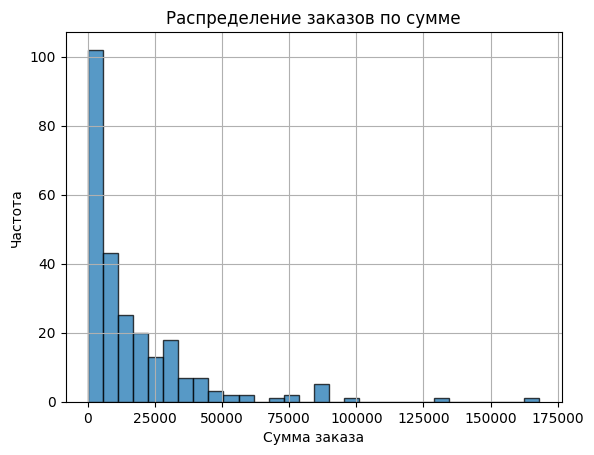

In [189]:
orders_ab['total_price'].plot(
                kind='hist', 
                bins=30, 
                alpha=0.75,
                edgecolor='black',
)

plt.title('Распределение заказов по сумме')
plt.xlabel('Сумма заказа')
plt.ylabel('Частота')

plt.grid()

plt.show() 

In [190]:
orders_ab['total_price'].quantile(0.99)

94312.57079999988

Отфильтруем данные по 99 перцентилю, чтобы исключить выбросы, которые могут искажать результат.

In [191]:
outliners=orders_ab[orders_ab['total_price']>orders_ab['total_price'].quantile(0.99)]['total_price']


In [192]:
orders_ab=orders_ab[~orders_ab['total_price'].isin(outliners)]
orders_ab.shape


(250, 11)

Очищенный датасет содержит 250 строк и 11 столбцов.

#### Датасет `users_ab` (`pa_marketplace_users_AB`)

In [193]:
users_ab.head()

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,18,2024-01-01 05:26:00,49,M,Екатеринбург,TikTok,one_time,2024-01-01,2024-01-01
1,22,2024-01-01 17:13:00,50,M,Санкт-Петербург,TikTok,one_time,2024-01-01,2024-01-01
2,26,2024-01-01 21:15:00,60,F,Москва,TikTok,rare,2024-01-01,2024-01-01
3,33,2024-01-01 14:43:00,31,M,Екатеринбург,TikTok,rare,2024-01-01,2024-01-01
4,39,2024-01-01 01:13:00,44,M,Санкт-Петербург,TikTok,rare,2024-01-01,2024-01-01


In [194]:
users_ab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22196 entries, 0 to 22195
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            22196 non-null  int64         
 1   registration_date  22196 non-null  datetime64[ns]
 2   age                22196 non-null  int64         
 3   gender             22196 non-null  object        
 4   region             22196 non-null  object        
 5   acq_channel        22196 non-null  object        
 6   buyer_segment      22196 non-null  object        
 7   cohort_week        22196 non-null  datetime64[ns]
 8   cohort_month       22196 non-null  datetime64[ns]
dtypes: datetime64[ns](3), int64(2), object(4)
memory usage: 1.5+ MB


Датасет представлен 22196 строками и 9 столбцами, данные и типы соответствуют описанию, пропуски отсутствуют.

In [195]:
users_ab.duplicated().sum()

0

Явные дубликаты отсутствуют.

In [196]:
users_ab[users_ab.duplicated(subset=['user_id'],keep=False)]

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month


In [197]:
users_ab[users_ab.duplicated(subset=['registration_date','age','gender','acq_channel','region'],keep=False)]

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
16990,41997,2024-12-11 04:06:00,40,F,Другие регионы,TikTok,rare,2024-12-09,2024-12-01
17025,42047,2024-12-11 04:06:00,40,F,Другие регионы,TikTok,medium,2024-12-09,2024-12-01
21766,48315,2025-01-23 13:08:00,68,M,Москва,TikTok,one_time,2025-01-20,2025-01-01
21862,48441,2025-01-23 13:08:00,68,M,Москва,TikTok,rare,2025-01-20,2025-01-01


Обнаружено 4 дубликата по столбцам `registration_date, age, gender , acq_channel , region`. Проверим, необходимо ли нам определять истинность этих дубликатов - участвуют пользователи с этими user_id в тестировании - объединим с данными сплита.

In [198]:
merged=pd.merge(users_ab,ab_split_users,on='user_id',how='inner')

In [199]:
merged[merged.duplicated(subset=['registration_date','age','gender','acq_channel','region'],keep=False)]

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month,group
2538,48315,2025-01-23 13:08:00,68,M,Москва,TikTok,one_time,2025-01-20,2025-01-01,control
2634,48441,2025-01-23 13:08:00,68,M,Москва,TikTok,rare,2025-01-20,2025-01-01,treatment


В объединенном датасете остались 2 строки с повторяющимися значениями по всем столбцам, кроме user_id, buyer_segment и group. Поскольку все данные о пользователе совпадают, а группы указаны разные, то для надежности (чтобы гарантировано не было пересечений групп) удалим обе строки из датасета.

In [200]:
users_ab=pd.merge(users_ab,ab_split_users,on='user_id',how='inner').drop_duplicates(subset=['registration_date','age','gender','acq_channel','region'],keep=False)

In [201]:
users_ab.head()

,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month,group
0,44965,2025-01-01 18:10:00,66,M,Новосибирск,TikTok,one_time,2024-12-30,2025-01-01,control
1,44967,2025-01-01 11:29:00,70,M,Московская область,TikTok,rare,2024-12-30,2025-01-01,control
2,44968,2025-01-01 13:05:00,68,F,Нижний Новгород,TikTok,regular,2024-12-30,2025-01-01,control
3,44969,2025-01-01 00:23:00,24,F,Краснодар,TikTok,medium,2024-12-30,2025-01-01,treatment
4,44970,2025-01-01 06:33:00,50,M,Санкт-Петербург,TikTok,regular,2024-12-30,2025-01-01,control


In [202]:
users_ab.shape

(2966, 10)

В отфильтрованном датасете осталось 2966 строк и 10 столбцов.

Для удобства последующего анализа сохраним списки пользователей из контрольной и тестовой групп

In [203]:
control_group=users_ab[users_ab['group']=='control']['user_id']


In [204]:
test_group=users_ab[users_ab['group']=='treatment']['user_id'].tolist()


### Проверка групп на сопоставимость

Проверим, есть ли существенные различия в группах по таким характеристикам пользователей, как регион, покупательский сегмент, пол.

In [205]:
round(users_ab.groupby('group')['region'].value_counts(normalize=True).unstack(),3)

region,Другие регионы,Екатеринбург,Краснодар,Москва,Московская область,Нижний Новгород,Новосибирск,Ростов-на-Дону,Санкт-Петербург
group,,,,,,,,,
control,0.324,0.045,0.042,0.246,0.077,0.043,0.043,0.026,0.153
treatment,0.337,0.049,0.031,0.245,0.082,0.040,0.034,0.031,0.150


In [206]:
round(users_ab.groupby('group')['buyer_segment'].value_counts(normalize=True).unstack(),3)

buyer_segment,medium,one_time,rare,regular
group,,,,
control,0.359,0.142,0.304,0.195
treatment,0.362,0.168,0.294,0.176


In [207]:
round(users_ab.groupby('group')['gender'].value_counts(normalize=True).unstack(),3)

gender,F,M
group,,
control,0.496,0.504
treatment,0.523,0.477


Различия в возрасте можем оценить с помощью метода describe().

In [208]:
round(users_ab.groupby('group')['age'].describe(),3)

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
control,1502.0,43.728,15.287,18.0,30.25,43.0,57.0,70.0
treatment,1464.0,44.309,15.029,18.0,31.00,44.0,58.0,70.0


В характеристиках пользователей из тестовой и контрольной групп есть некоторая вариативность, однако, отсутствуют существенные различия. Предложенный сплит можно использовать для дальнейшего анализа.

In [209]:
#Соберем данные расчетов групп для будущей сводной таблицы

users_qty_ab=['Количество пользователей', users_ab[users_ab['group']=='treatment']['user_id'].nunique(),len(control_group),round(len(test_group)/len(control_group)*100-100),np.nan]
buyers_qty_ab=['Количество покупателей', orders_ab[orders_ab['group']=='treatment']['user_id'].nunique(),orders_ab[orders_ab['group']=='control']['user_id'].nunique(),round(orders_ab[orders_ab['group']=='treatment']['user_id'].nunique()/orders_ab[orders_ab['group']=='control']['user_id'].nunique()*100-100),np.nan]

### Расчет ключевой метрики (конверсия в первую покупку)

Поскольку все пользователи являются новыми, то конверсия в первую покупку - это то же самое, что конверсия в заказ, и будет вычисляться по формуле: количество пользователей, разместивших заказ разделить на общее количество пользователей. 

In [210]:
cr_test=orders_ab[orders_ab['group']=='treatment']['user_id'].nunique()/users_ab[users_ab['group']=='treatment']['user_id'].nunique()
round(cr_test,4)

0.0745

In [211]:
cr_control=orders_ab[orders_ab['group']=='control']['user_id'].nunique()/users_ab[users_ab['group']=='control']['user_id'].nunique()
round(cr_control,4)

0.0107

Для оценки статистической значимости изменений применим z-тест пропорций. 

Гипотезы:

H0 - конверсия в тестовой группе равна конверсии в контрольной группе.

Н1 - конверсия в тестовой группе выше, чем конверсия в контрольной группе

In [212]:
success = [orders_ab[orders_ab['group']=='treatment']['user_id'].nunique(), orders_ab[orders_ab['group']=='control']['user_id'].nunique()]   # количество целевых событий (конверсий) в группе А и Б
nobs = [users_ab[users_ab['group']=='treatment']['user_id'].nunique(), users_ab[users_ab['group']=='control']['user_id'].nunique()]    # размеры групп

_, p_value_cr = proportions_ztest(success, nobs, alternative='larger')

print(f'Конверсия в покупку (тест) {cr_test:.4f}')
print(f'Конверсия в покупку (контроль) {cr_control:.4f}')
print(f"p-value: {p_value_cr:.4f}")

if p_value_cr < 0.05:
    print("Конверсия в тестовой группе выше, чем в контрольной (отвергаем H0)")
else:
    print("Конверсия в тестовой группе равна конверсии в контрольной (не можем отвергнуть H0)")

Конверсия в покупку (тест) 0.0745
Конверсия в покупку (контроль) 0.0107
p-value: 0.0000
Конверсия в тестовой группе выше, чем в контрольной (отвергаем H0)


In [213]:
#Соберем данные расчетов для будущей сводной таблицы
cr_ab=['Конверсия, %',round(cr_test*100,2),round(cr_control*100,2),round(cr_test/cr_control*100-100),round(p_value_cr,4)]


Можно утверждать, что конверсия в заказ в тестовой группе выросла по сравнению с контрольной. Теперь необходимо рассчитать вспомогательные и барьерную метрики.

### Расчет вспомогательных метрик

**ARPU (средняя выручка на пользователя TikTok)**

Рассчитаем средние значения выручки с пользователя в тестовой и контрольной группах.

In [214]:
arpu_test=orders_ab[orders_ab['group']=='treatment'].groupby('user_id')['total_price'].sum()*0.05
round(arpu_test.sum()/len(test_group))

117

In [215]:
arpu_control=orders_ab[orders_ab['group']=='control'].groupby('user_id')['total_price'].sum()*0.05
round(arpu_control.sum()/len(control_group))

13

Для оценки статистической значимости изменений применим тест Манна-Уитни. 

Гипотезы:

H0 - средняя выручка на пользователя в тестовой группе равна средней выручке на пользователя в контрольной группе.

Н1 - средняя выручка на пользователя в тестовой группе выше, чем средней выручке на пользователя в контрольной группе

In [216]:
# # Добавляем пользователей без покупок
arpu_test = arpu_test.reindex(test_group,fill_value=0)
arpu_control = arpu_control.reindex(control_group, fill_value=0)

In [217]:
_, p_value_arpu = mannwhitneyu(arpu_test, arpu_control, alternative='greater')

print(f"ARPU treatment: {arpu_test.mean():.2f}")
print(f"ARPU control: {arpu_control.mean():.2f}")
print(f"p-value: {p_value_arpu:.4f}")

if p_value_arpu < 0.05:
    print("ARPU в тестовой группе выше, чем в контрольной (отвергаем H0)")
else:
    print("Разница в ARPU статистически не значима (не можем отвергнуть H0)")

ARPU treatment: 117.45
ARPU control: 12.60
p-value: 0.0000
ARPU в тестовой группе выше, чем в контрольной (отвергаем H0)


In [218]:
#Соберем данные расчетов для будущей сводной таблицы
arpu_ab=['ARPU',round(arpu_test.mean(),2),round(arpu_control.mean(),2),round(arpu_test.mean()/arpu_control.mean()*100-100),round(p_value_arpu,4)]


In [219]:
arpu_ab

['ARPU', 117.45, 12.6, 832, 0.0]

Средняя выручка на пользователя выросла.

**ARPPU (средняя выручка на покупателя TikTok)**


Рассчитаем средние значения выручки с покупателя в тестовой и контрольной группах.

In [220]:
arppu_test=orders_ab[orders_ab['group']=='treatment']['total_price'].sum()*0.05/orders_ab[orders_ab['group']=='treatment']['user_id'].nunique()
round(arppu_test)

1577

In [221]:
arppu_control=orders_ab[orders_ab['group']=='control']['total_price'].sum()*0.05/orders_ab[orders_ab['group']=='control']['user_id'].nunique()
round(arppu_control)

1182

Для оценки статистической значимости изменений применим тест Манна-Уитни. 

Гипотезы:

H0 - средняя выручка на покупателя в тестовой группе равна средней выручке на покупателя в контрольной группе.

Н1 - средняя выручка на покупателя в тестовой группе выше, чем средней выручке на покупателя в контрольной группе

In [222]:
revenue_per_buyer_test = orders_ab[orders_ab['group'] == 'treatment'].groupby('user_id')['total_price'].sum()*0.05
revenue_per_buyer_control = orders_ab[orders_ab['group'] == 'control'].groupby('user_id')['total_price'].sum()*0.05


print(f"ARPPU treatment: {revenue_per_buyer_test.mean():.2f}")
print(f"ARPPU control: {revenue_per_buyer_control.mean():.2f}")

_, p_value_arppu = mannwhitneyu(revenue_per_buyer_test, revenue_per_buyer_control, alternative='two-sided')

print(f"p-value: {p_value_arppu:.6f}")

if p_value_arppu < 0.05:
    print("Разница в ARPPU статистически значима (отвергаем H0)")
else:
    print("Разница в ARPPU статистически не значима (не можем отвергнуть H0)")

ARPPU treatment: 1577.50
ARPPU control: 1182.42
p-value: 0.471213
Разница в ARPPU статистически не значима (не можем отвергнуть H0)


In [223]:
#Соберем данные расчетов для будущей сводной таблицы
arppu_ab=['ARPPU',round(revenue_per_buyer_test.mean()),round(revenue_per_buyer_control.mean()),round(revenue_per_buyer_test.mean()/revenue_per_buyer_control.mean()*100-100),round(p_value_arppu,4)]


В средней выручке на покупателя нет статистически значимых изменений. В совокупностью с ростом APRU это означает, что увеличилась доля покупателей (то есть конверсия), а средняя сумма, которую они тратят, не изменилась.

**AOV (средний чек TikTok)**


Рассчитаем средний чек заказа в тестовой и контрольной группах.

In [224]:
aov_test=orders_ab[orders_ab['group']=='treatment']['total_price'].sum()/orders_ab[orders_ab['group']=='treatment']['order_id'].nunique()
round(aov_test)

15217

In [225]:
aov_control=orders_ab[orders_ab['group']=='control']['total_price'].sum()/orders_ab[orders_ab['group']=='control']['order_id'].nunique()
round(aov_control)

15766

Для оценки статистической значимости изменений применим тест Манна-Уитни.

Гипотезы:

H0 - Средний чек в тестовой группе равен среднему чеку в контрольной группе.

Н1 - Средний чек в тестовой группе и средний чек в контрольной группе не равны.

In [226]:
total_price_test = orders_ab[orders_ab['group'] == 'treatment']['total_price']
total_price_control = orders_ab[orders_ab['group'] == 'control']['total_price']

_, p_value_aov = mannwhitneyu(total_price_test, total_price_control, alternative='two-sided')

print(f"AOV treatment: {total_price_test.mean():.2f}")
print(f"AOV control: {total_price_control.mean():.2f}")
print(f"p-value: {p_value_aov:.4f}")

if p_value_aov < 0.05:
    print("Разница в среднем чеке статистически значима (отвергаем H0)")
else:
    print("Разница в среднем чеке статистически не значима (не можем отвергнуть H0)")


AOV treatment: 15216.58
AOV control: 15765.54
p-value: 0.2362
Разница в среднем чеке статистически не значима (не можем отвергнуть H0)


In [227]:
#Соберем данные расчетов для будущей сводной таблицы
aov_ab=['AOV',round(aov_test.mean()),round(aov_control.mean()),round(aov_test.mean()/aov_control.mean()*100-100),round(p_value_aov,4)]


Средний чек не изменился, покупатели в среднем размещают заказы на те же суммы, что и без бонусов на покупку. 

### Барьерная метрика
**Общая выручка от пользователей TikTok**


In [228]:
round(orders_ab.groupby('group')['total_price'].sum()*0.05)

group
control       18919.0
treatment    171947.0
Name: total_price, dtype: float64

In [229]:
print(f"Разница в общей выручке - в {round(orders_ab[orders_ab['group']=='treatment']['total_price'].sum()/orders_ab[orders_ab['group']=='control']['total_price'].sum(),2)} раз, в пользу тестовой группы.")

Разница в общей выручке - в 9.09 раз, в пользу тестовой группы.


Барьерная метрика - общая выручка с пользователей - не снижается. Это позволяет говорить о том, что внедрение не имело негативного эффекта на продукт.

In [230]:
#Соберем данные расчетов для будущей сводной таблицы
revenue_ab=['Общая выручка',round(orders_ab[orders_ab['group']=='treatment']['total_price'].sum()*0.05),round(orders_ab[orders_ab['group']=='control']['total_price'].sum()*0.05),round(orders_ab[orders_ab['group']=='treatment']['total_price'].sum()/orders_ab[orders_ab['group']=='control']['total_price'].sum()*100-100),np.nan]

In [231]:
metrics_ab = pd.DataFrame([users_qty_ab,buyers_qty_ab,cr_ab, arpu_ab, arppu_ab, aov_ab, revenue_ab],
                          columns=['Метрика', 'Treatment', 'Control', 'Изменение, %', 'p-value'])
metrics_ab['Изменение, %'] = metrics_ab['Изменение, %'].apply(lambda x: f"+{x:.0f}%" if x > 0 else f"{x:.0f}%")
metrics_ab_formatted = metrics_ab.copy()

# Преобразуем числовые колонки в обычный формат
for col in ['Treatment', 'Control']:
    metrics_ab_formatted[col] = metrics_ab_formatted[col].apply(lambda x: f"{x:.0f}" if x == int(x) else f"{x:.2f}")



In [232]:
metrics_ab_formatted['Стат. значимость'] = metrics_ab_formatted['p-value'].apply(
    lambda x: "-" if pd.isna(x) else ("Значимо" if x < 0.05 else "Не значимо")
)


## Выводы по этапу 5

### Результаты A/B теста: бонус на первую покупку (TikTok)

### Сводная таблица метрик
<!-- 
| Метрика | Treatment | Control | Изменение | p-value | Статистическая значимость |
|---------|-----------|---------|-----------|---------|---------------------------|
| **Количество пользователей** | 1 464 | 1 502 | -3% | — | — |
| **Количество покупателей** | 109 | 16 | **+581%** | — | — |
| **Конверсия в покупку** | 7.45% | 1.07% | **+599%** | 0.0000 | **Значимо** |
| **ARPU** | 117 ₽ | 13 ₽ | **+832%** | 0.0000 | **Значимо** |
| **ARPPU** | 1 577 ₽ | 1 182 ₽ | +33% | 0.4712 | Не значимо |
| **AOV** | 15 217 ₽ | 15 766 ₽ | -3% | 0.2362 | Не значимо |
| **Общая выручка** | 171 947 ₽ | 18 919 ₽ | **+809%** | — | — | -->


In [233]:
metrics_ab_formatted

,Метрика,Treatment,Control,"Изменение, %",p-value,Стат. значимость
0,Количество пользователей,1464,1502,-3%,NaN,-
1,Количество покупателей,109,16,+581%,NaN,-
2,"Конверсия, %",7.45,1.07,+599%,0.0000,Значимо
3,ARPU,117.45,12.60,+832%,0.0000,Значимо
4,ARPPU,1577,1182,+33%,0.4712,Не значимо
5,AOV,15217,15766,-3%,0.2362,Не значимо
6,Общая выручка,171947,18919,+809%,NaN,-


### Итоги эксперимента:

**1. Влияние на целевую аудиторию**

Бонус на первую покупку оказал сильное положительное влияние на поведение пользователей TikTok:

Конверсия выросла в 7 раз (с 1.07% до 7.45%)

Количество покупателей увеличилось в 6.8 раз (с 16 до 109 человек)

Размеры групп сопоставимы (1 464 vs 1 502), исключая влияние дисбаланса

**2. Экономический эффект**

ARPU вырос в 9.3 раза (с 12.6 ₽ до 117.5₽)

Общая выручка выросла в 9.1 раза (с 18.9 тыс. до 171.9 тыс ₽)

**3. Качество покупателей**

Важно отметить, что качество привлечённых покупателей не изменилось:

ARPPU (средняя выручка на покупателя) не отличается статистически (p=0.4712)

AOV (средний чек) не отличается статистически (p=0.2362)

Это означает, что бонус не стимулирует существующих покупателей тратить больше, а привлекает новых покупателей с таким же чеком. Эффект достигается исключительно за счёт роста конверсии.



### Итоговый вердикт по эксперименту
Бонус на первую покупку для пользователей TikTok доказал свою эффективность.

**Рекомендации:**
- Внедрить бонусную программу для TikTok
- Оценить юнит-экономику (в частности, ROI )
- Рассмотреть распространение бонуса на другие каналы
- Протестировать разные размеры бонуса